# Датасет **House Prices - Advanced Regression Techniques**. 
*Хороший датасет для тренировки Feature Engineering и проведения EDA.*

https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

In [2]:
# импорт библиотек
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
# игнорируем бесячие предупреждения
import warnings
warnings.filterwarnings('ignore')

In [4]:
# извлекаем датасеи из .csv и настраиваем отображение
df = pd.read_csv('data/train.csv')
pd.set_option('display.max_rows', None) #отображение всех строк
pd.set_option('display.max_columns', None) #отображение всех столбцов


## A) Быстрый обзор данных (Pandas)

df.head(), df.tail(), df.shape.

In [5]:
print("Df.shape: ",df.shape)
display(df.head())
display(df.tail())

Df.shape:  (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,Norm,1Fam,2Story,6,5,1999,2000,Gable,CompShg,VinylSd,VinylSd,NaN,0.0,TA,TA,PConc,Gd,TA,No,Unf,0,Unf,0,953,953,GasA,Ex,Y,SBrkr,953,694,0,1647,0,0,2,1,3,1,TA,7,Typ,1,TA,Attchd,1999.0,RFn,2,460,TA,TA,Y,0,40,0,0,0,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,Norm,1Fam,1Story,6,6,1978,1988,Gable,CompShg,Plywood,Plywood,Stone,119.0,TA,TA,CBlock,Gd,TA,No,ALQ,790,Rec,163,589,1542,GasA,TA,Y,SBrkr,2073,0,0,2073,1,0,2,0,3,1,TA,7,Min1,2,TA,Attchd,1978.0,Unf,2,500,TA,TA,Y,349,0,0,0,0,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,9,1941,2006,Gable,CompShg,CemntBd,CmentBd,NaN,0.0,Ex,Gd,Stone,TA,Gd,No,GLQ,275,Unf,0,877,1152,GasA,Ex,Y,SBrkr,1188,1152,0,2340,0,0,2,0,4,1,Gd,9,Typ,2,Gd,Attchd,1941.0,RFn,1,252,TA,TA,Y,0,60,0,0,0,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,5,6,1950,1996,Hip,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,TA,TA,Mn,GLQ,49,Rec,1029,0,1078,GasA,Gd,Y,FuseA,1078,0,0,1078,1,0,1,0,2,1,Gd,5,Typ,0,NaN,Attchd,1950.0,Unf,1,240,TA,TA,Y,366,0,112,0,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Edwards,Norm,Norm,1Fam,1Story,5,6,1965,1965,Gable,CompShg,HdBoard,HdBoard,NaN,0.0,Gd,TA,CBlock,TA,TA,No,BLQ,830,LwQ,290,136,1256,GasA,Gd,Y,SBrkr,1256,0,0,1256,1,0,1,1,3,1,TA,6,Typ,0,NaN,Attchd,1965.0,Fin,1,276,TA,TA,Y,736,68,0,0,0,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


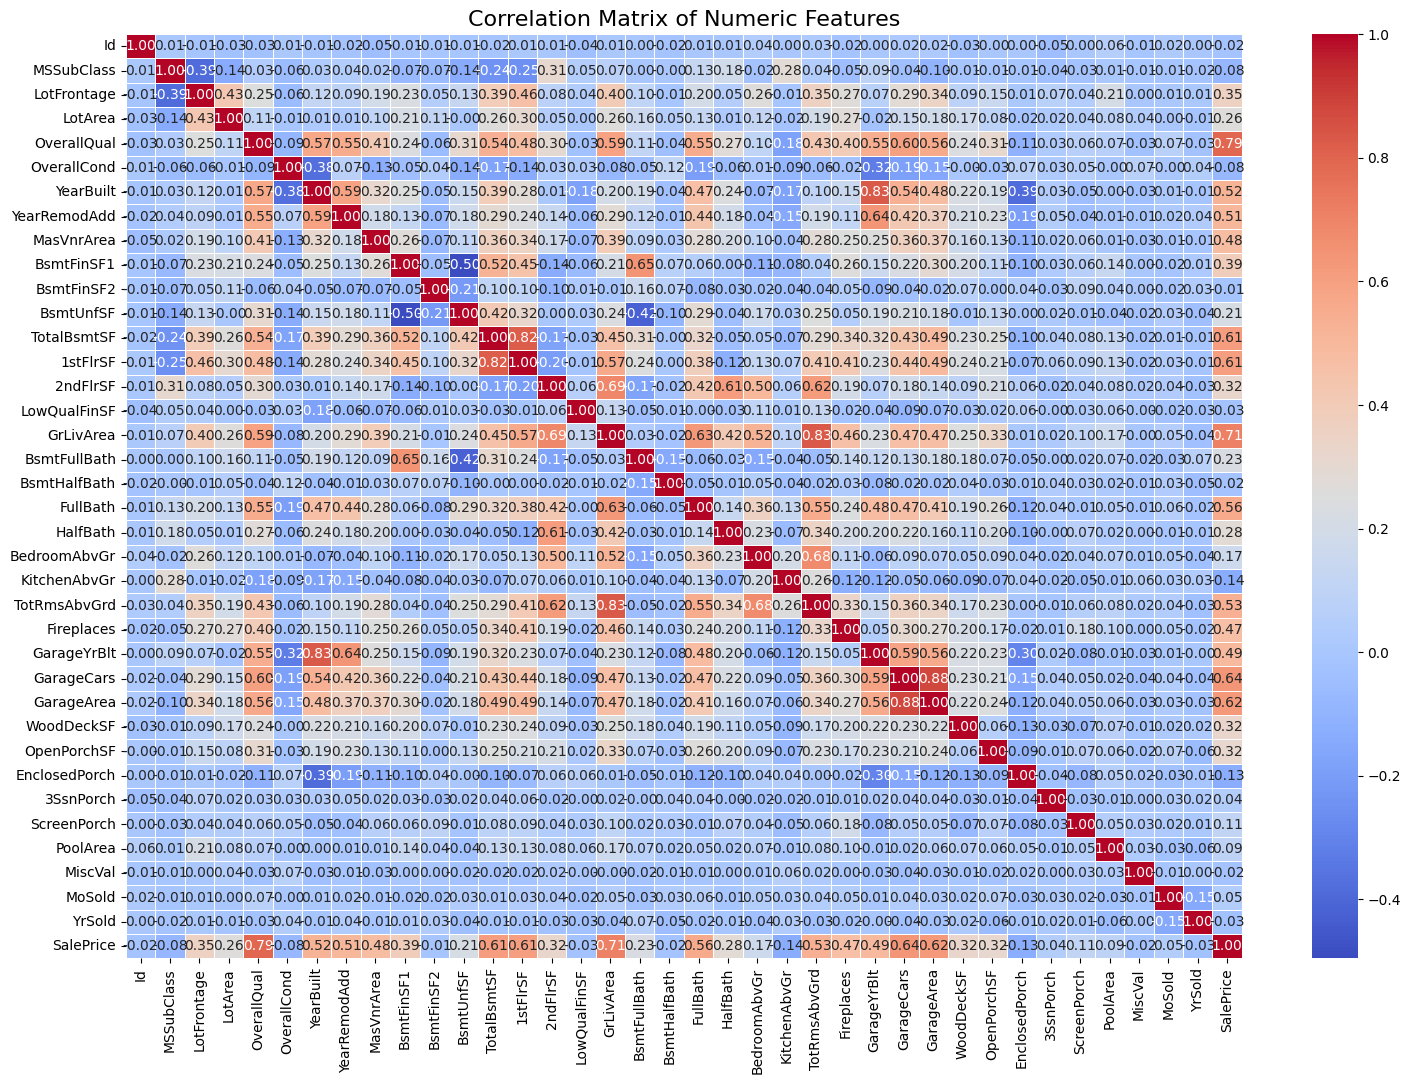

In [6]:
# Построим матрицу корреляции для числовых столбцов
plt.figure(figsize=(18, 12))
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontsize=16)
plt.show()

In [7]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# Собираем список всего, что нужно удалить:
# 1. Исходные годы (они заменены на возраст)
# 2. Информационный шум (бассейны, аллеи)
# 3. Дублирующие площади (мультиколлинеарность)
cols_to_drop =[
    'YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'YrSold', 
    'Utilities', 'Street', 'PoolQC', 'PoolArea', 'MiscFeature', 'MiscVal', 'Alley',
    'GarageArea', 'TotRmsAbvGrd', '1stFlrSF', '2ndFlrSF'
]

# Удаляем колонки (errors='ignore' спасет от ошибки при случайном повторном запуске ячейки)
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# Проверяем, что получилось:
print("Размер датасета после очистки:", df.shape)
display(df.head(3))

Размер датасета после очистки: (1460, 67)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,Fence,MoSold,SaleType,SaleCondition,SalePrice,HouseAge
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,0,1710,1,0,2,1,3,1,Gd,Typ,0,NaN,Attchd,RFn,2,TA,TA,Y,0,61,0,0,0,NaN,2,WD,Normal,208500,5
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,0,1262,0,1,2,0,3,1,TA,Typ,1,TA,Attchd,RFn,2,TA,TA,Y,298,0,0,0,0,NaN,5,WD,Normal,181500,31
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,0,1786,1,0,2,1,3,1,Gd,Typ,1,TA,Attchd,RFn,2,TA,TA,Y,0,42,0,0,0,NaN,9,WD,Normal,223500,7


df.info() и df.describe() (отдельно .describe(include="object") для строк)

In [8]:
df.info()
display(df.describe()) # анализ: числовые значения
display(df.describe(include="object")) # анализ только строковых значений
                                        # include="all" для всего

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 67 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   LotShape       1460 non-null   str    
 6   LandContour    1460 non-null   str    
 7   LotConfig      1460 non-null   str    
 8   LandSlope      1460 non-null   str    
 9   Neighborhood   1460 non-null   str    
 10  Condition1     1460 non-null   str    
 11  Condition2     1460 non-null   str    
 12  BldgType       1460 non-null   str    
 13  HouseStyle     1460 non-null   str    
 14  OverallQual    1460 non-null   int64  
 15  OverallCond    1460 non-null   int64  
 16  RoofStyle      1460 non-null   str    
 17  RoofMatl       1460 non-null   str    
 18  Exterior1st    1460

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,Fireplaces,GarageCars,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MoSold,SalePrice,HouseAge
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,103.685262,443.639726,46.549315,567.240411,1057.429452,5.844521,1515.463699,0.425342,0.057534,1.565068,0.382877,2.866438,1.046575,0.613014,1.767123,94.244521,46.660274,21.954110,3.409589,15.060959,6.321918,180921.195890,36.547945
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,181.066207,456.098091,161.319273,441.866955,438.705324,48.623081,525.480383,0.518911,0.238753,0.550916,0.502885,0.815778,0.220338,0.644666,0.747315,125.338794,66.256028,61.119149,29.317331,55.757415,2.703626,79442.502883,30.250152
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,34900.000000,0.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,0.000000,0.000000,0.000000,223.000000,795.750000,0.000000,1129.500000,0.000000,0.000000,1.000000,0.000000,2.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,129975.000000,8.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,0.000000,383.500000,0.000000,477.500000,991.500000,0.000000,1464.000000,0.000000,0.000000,2.000000,0.000000,3.000000,1.000000,1.000000,2.000000,0.000000,25.000000,0.000000,0.000000,0.000000,6.000000,163000.000000,35.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,166.000000,712.250000,0.000000,808.000000,1298.250000,0.000000,1776.750000,1.000000,0.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000,168.000000,68.000000,0.000000,0.000000,0.000000,8.000000,214000.000000,54.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,1600.000000,5644.000000,1474.000000,2336.000000,6110.000000,572.000000,5642.000000,3.000000,2.000000,3.000000,2.000000,8.000000,3.000000,3.000000,4.000000,857.000000,547.000000,552.000000,508.000000,480.000000,12.000000,755000.000000,136.000000


,MSZoning,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,Heating,HeatingQC,CentralAir,Electrical,KitchenQual,Functional,FireplaceQu,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,Fence,SaleType,SaleCondition
count,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,588,1460,1460,1460,1423,1423,1422,1423,1422,1460,1460,1460,1459,1460,1460,770,1379,1379,1379,1379,1460,281,1460,1460
unique,5,4,4,5,3,25,9,8,5,8,6,8,15,16,3,4,5,6,4,4,4,6,6,6,5,2,5,4,7,5,6,3,5,5,3,4,9,6
top,RL,Reg,Lvl,Inside,Gtl,NAmes,Norm,Norm,1Fam,1Story,Gable,CompShg,VinylSd,VinylSd,BrkFace,TA,TA,PConc,TA,TA,No,Unf,Unf,GasA,Ex,Y,SBrkr,TA,Typ,Gd,Attchd,Unf,TA,TA,Y,MnPrv,WD,Normal
freq,1151,925,1311,1052,1382,225,1260,1445,1220,726,1141,1434,515,504,445,906,1282,647,649,1311,953,430,1256,1428,741,1365,1334,735,1360,380,870,605,1311,1326,1340,157,1267,1198


Проверка качества №1: isnull().sum() + графики


Missing Values: 
 Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
LotShape            0
LandContour         0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
LowQualFinSF        0
GrLivArea           0
BsmtFullBath        0
BsmtHalfBath        0
FullBath            0
HalfBath            0
BedroomAbvGr 

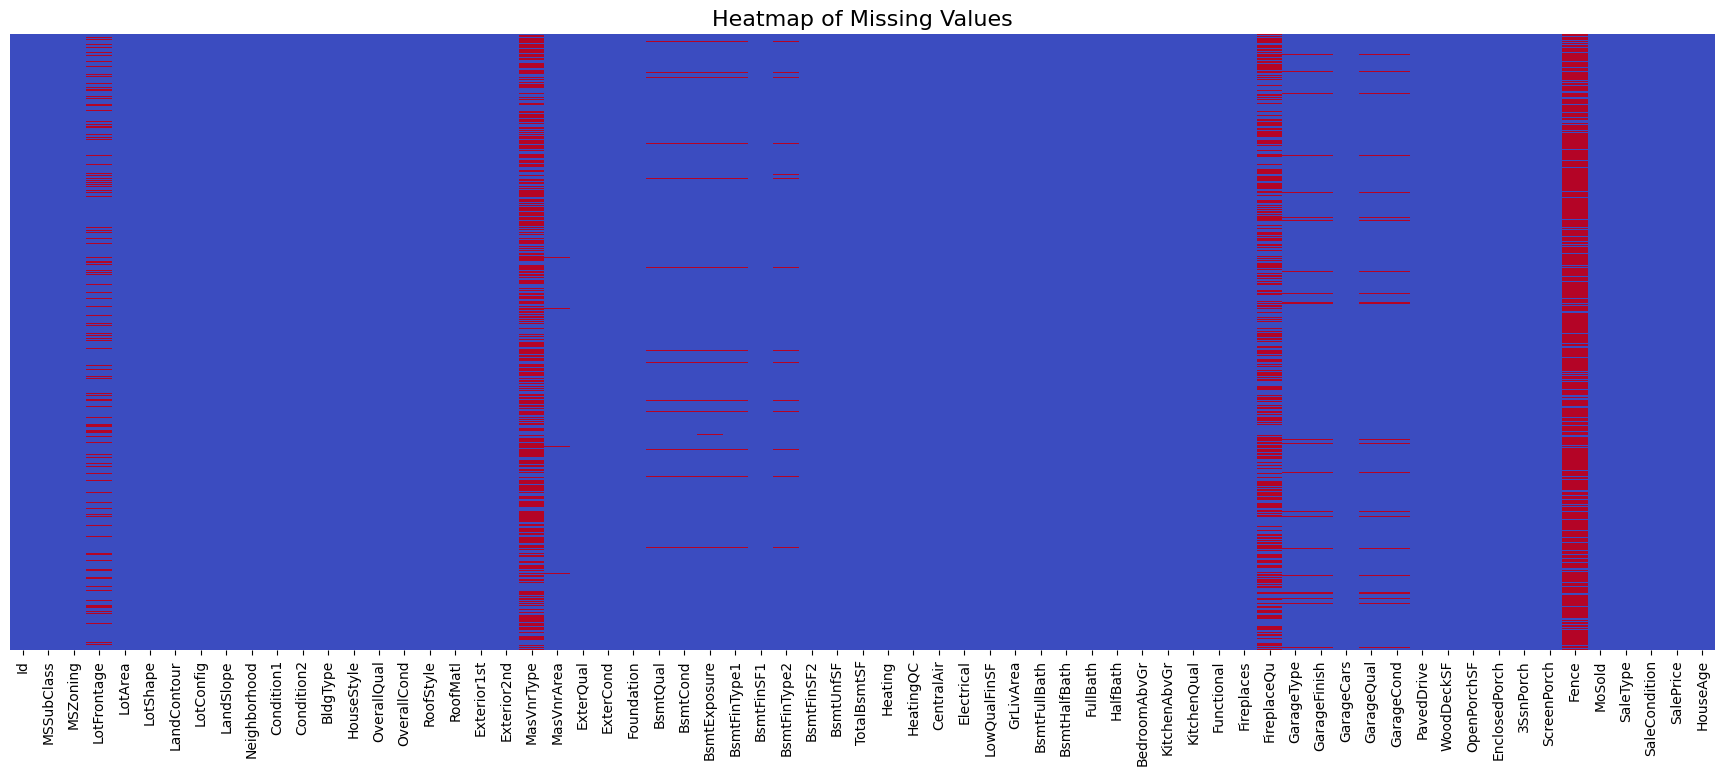

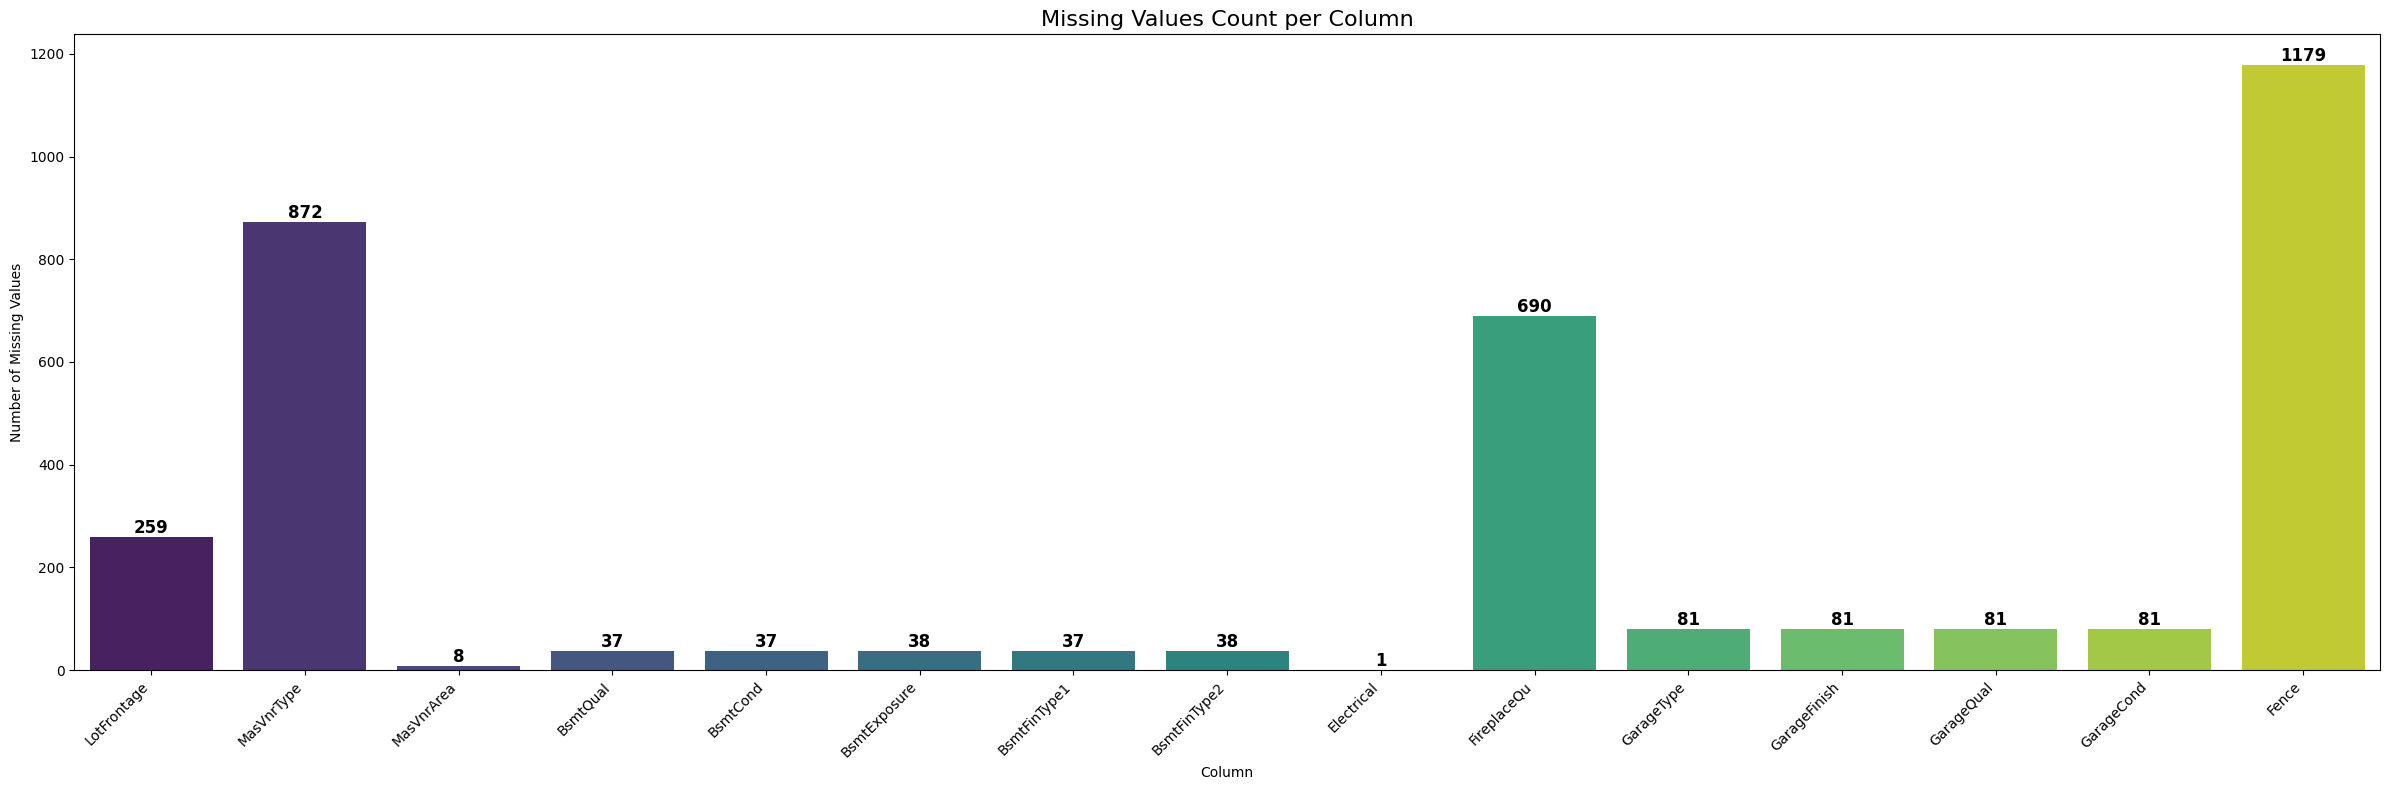

In [9]:
# проверка на пропущенные значения
missing_counts = df.isnull().sum()
print("\nMissing Values: \n",missing_counts)
print("\nPercent of Missing Values: \n",missing_counts/len(df)*100,"%")
print("\nColumns with Missing Values: \n", missing_counts[missing_counts > 0])

# наглядное представление пропусков значений - тепловая карта
plt.figure(figsize=(22, 8))
sns.heatmap(df.isnull(), cbar=False, cmap='coolwarm', yticklabels=False)
plt.title('Heatmap of Missing Values', fontsize=16)
plt.show()

# наглядное представление только пропущенных значений - столбчатая диаграмма
cols_with_missing = missing_counts[missing_counts > 0]

plt.figure(figsize=(24, 8))
ax = sns.barplot(x=cols_with_missing.index, y=cols_with_missing.values, palette='viridis')
plt.title('Missing Values Count per Column', fontsize=16)
plt.ylabel('Number of Missing Values')
plt.xlabel('Column')

# добавление значения количества пропущенных значений на каждую колонку
for i, count in enumerate(cols_with_missing.values):
    ax.text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Вывод: большое количество пропущенных данных, особенно в катгориальных колонках

Проверка качества №2: поиск дубликатов

In [10]:
print(f"Number of Duplicates: {df.duplicated().sum()}")

Number of Duplicates: 0


Вывод: дупликатов нет

Проверка качества №3: проверка адекватности типов данных

Вывод: данные адекватны

## B) Пропуски и очистка

Покажите стратегии dropna() и fillna(). Заполняйте средним, медианой, константой — и обязательно обоснуйте выбор текстовым комментарием.

Вывод: нет строк без пропусков, поэтому этот метод отсеивания данных не подходит.

Попробуем заполнить пропуски разными значениями. Категориальные в осноном будем заполнять значением 'No*' или модой, числовые же медианами (или 0, если это имеет смысл).

Например, значения LotFrontage заполняем медианами ПО ГРУППАМ LotConfig, так как само наличие LotConfig показывает, что LotFrontage не должен быть пустой. Чтобы не допустить выбросов, будем находить медиану именно по значениям LotConfig, а не медиану всех имеющихся значений LotFrontage.

In [11]:
# Заполнение пропущенных значений LotFrontage медианой внутри каждой группы LotConfig
df_corrected = df.copy()
df_corrected['LotFrontage'] = df.groupby('LotConfig')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)

df_corrected['MasVnrType'] = df_corrected['MasVnrType'].fillna('NoVrn')  # нет облицовки

# MasVnrArea: пропуски заменить на 0 (нет площади облицовки)
df_corrected['MasVnrArea'] = df_corrected['MasVnrArea'].fillna(0)

# BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1, BsmtFinType2: пропуски заменить на "NoBasement"
for col in ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2']:
    df_corrected[col] = df_corrected[col].fillna('NoBasement')  # нет подвала

# Electrical: заполнить пропуски модой по колонке (самое частое значение электропроводки)
electrical_mode = df_corrected['Electrical'].mode(dropna=True)[0]
df_corrected['Electrical'] = df_corrected['Electrical'].fillna(electrical_mode)

# FireplaceQu:
# Если в Fireplaces==0, пропуск FireplaceQu -> "None", иначе (если встретится) заполняем модой
# (обычно FireplaceQu пустая только если печей нет)
fireplacequ_mode = df_corrected['FireplaceQu'].mode(dropna=True)[0]
def fill_fireplacequ(row):
    if pd.isna(row['FireplaceQu']):
        return "None" if row['Fireplaces'] == 0 else fireplacequ_mode
    else:
        return row['FireplaceQu']

df_corrected['FireplaceQu'] = df_corrected.apply(fill_fireplacequ, axis=1)

# GarageType, GarageFinish, GarageQual, GarageCond: заполнить "NoGarage"
for col in ['GarageType', 'GarageFinish', 'GarageQual', 'GarageCond']:
    df_corrected[col] = df_corrected[col].fillna('NoGarage')



# Fence: заполнить "NoFence"
df_corrected['Fence'] = df_corrected['Fence'].fillna('NoFence')

display(df_corrected.head())


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Functional,Fireplaces,FireplaceQu,GarageType,GarageFinish,GarageCars,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,Fence,MoSold,SaleType,SaleCondition,SalePrice,HouseAge
0,1,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,0,1710,1,0,2,1,3,1,Gd,Typ,0,None,Attchd,RFn,2,TA,TA,Y,0,61,0,0,0,NoFence,2,WD,Normal,208500,5
1,2,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,Gable,CompShg,MetalSd,MetalSd,NoVrn,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,0,1262,0,1,2,0,3,1,TA,Typ,1,TA,Attchd,RFn,2,TA,TA,Y,298,0,0,0,0,NoFence,5,WD,Normal,181500,31
2,3,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,0,1786,1,0,2,1,3,1,Gd,Typ,1,TA,Attchd,RFn,2,TA,TA,Y,0,42,0,0,0,NoFence,9,WD,Normal,223500,7
3,4,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,Gable,CompShg,Wd Sdng,Wd Shng,NoVrn,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,0,1717,1,0,1,0,3,1,Gd,Typ,1,Gd,Detchd,Unf,3,TA,TA,Y,0,35,272,0,0,NoFence,2,WD,Abnorml,140000,91
4,5,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,0,2198,1,0,2,1,4,1,Gd,Typ,1,TA,Attchd,RFn,3,TA,TA,Y,192,84,0,0,0,NoFence,12,WD,Normal,250000,8


Все значения были заменены на логичные (что доказуемо визуализацией). Только значение с годом постройки ОТСУТСВУЮЩИХ гаражей оставили пустым, чтобы они не влияли на вычисления с другими годами.

## C) Расширенная статистика

Для числовых колонок выведите: min, max, mean, median, mode.

In [12]:
# Для числовых колонок выведите: min, max, mean, median, mode.

# Выделим только числовые столбцы
num_columns = df_corrected.select_dtypes(include=['number']).columns

# Создадим DataFrame с min, max, mean, median
stats = df_corrected[num_columns].agg(['min', 'max', 'mean', 'median']).T

# Добавим mode
modes = df_corrected[num_columns].mode().iloc[0]
stats['mode'] = modes

display(stats.drop(index='Id')) #+исключили id


,min,max,mean,median,mode
MSSubClass,20.0,190.0,56.897260,50.0,20.0
LotFrontage,21.0,313.0,69.553425,68.0,68.0
LotArea,1300.0,215245.0,10516.828082,9478.5,7200.0
OverallQual,1.0,10.0,6.099315,6.0,5.0
OverallCond,1.0,9.0,5.575342,5.0,5.0
MasVnrArea,0.0,1600.0,103.117123,0.0,0.0
BsmtFinSF1,0.0,5644.0,443.639726,383.5,0.0
BsmtFinSF2,0.0,1474.0,46.549315,0.0,0.0
BsmtUnfSF,0.0,2336.0,567.240411,477.5,0.0
TotalBsmtSF,0.0,6110.0,1057.429452,991.5,0.0


Проверка выбросов методом 3х сигм

In [13]:
# Реализуем правило трех сигм для проверки выбросов для числовых столбцов

outliers_3sigma = {}
for col in num_columns:
    if col == 'Id':
        continue
    series = df_corrected[col].dropna()
    mean = series.mean()
    std = series.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    outliers_3sigma[col] = len(outliers)

outliers_3sigma_df = pd.DataFrame.from_dict(outliers_3sigma, orient='index', columns=['num_outliers'])

# Выводим таблицу с количеством выбросов, а также отдельно: Общее количество выбросов и Процент выбросов относительно всех данных
display(outliers_3sigma_df.sort_values('num_outliers', ascending=False))

total_outliers = outliers_3sigma_df['num_outliers'].sum()
total_values = df_corrected[num_columns].count().sum()
percent_outliers = (total_outliers / total_values) * 100
print(f"Общее количество выбросов по правилу трех сигм: {total_outliers}")
print(f"Процент выбросов относительно всех данных: {percent_outliers:.2f}%")

# Для числовых колонок рассчитаем границы по правилу трех сигм и отдельно выведем для SalePrice

three_sigma_ranges = {}
for col in num_columns:
    if col == 'Id':
        continue
    series = df_corrected[col].dropna()
    mean = series.mean()
    std = series.std()
    lower_bound = mean - 3 * std
    upper_bound = mean + 3 * std
    three_sigma_ranges[col] = (lower_bound, upper_bound)

# Выведем границы по правилу трех сигм по всем числовым колонкам (можно ограничиться SalePrice)
print("Диапазоны по правилу трех сигм для числовых признаков:")
for col, (low, up) in three_sigma_ranges.items():
    print(f"{col}: [{low:.2f}; {up:.2f}]")

# Для SalePrice отдельно выведем границы и количество выбросов
mean_sp = df_corrected["SalePrice"].mean()
std_sp = df_corrected["SalePrice"].std()
lower_sp = mean_sp - 3 * std_sp
upper_sp = mean_sp + 3 * std_sp
print(f"\nSalePrice - правило трех сигм: [{lower_sp:.2f}; {upper_sp:.2f}]")

outliers_sp = df_corrected[(df_corrected["SalePrice"] < lower_sp) | (df_corrected["SalePrice"] > upper_sp)]
import pandas as pd

# Создаем DataFrame с нужными статистиками по SalePrice
saleprice_stats = pd.DataFrame({
    "Метрика": [
        "Mean", 
        "Std", 
        "Нижняя граница (3σ)", 
        "Верхняя граница (3σ)", 
        "Число выбросов", 
        "Процент выбросов"
   
    ],
    "Значение": [
        f"${mean_sp:,.2f}",
        f"${std_sp:,.2f}",
        f"${lower_sp:,.2f}",
        f"${upper_sp:,.2f}",
        len(outliers_sp),
        f"{len(outliers_sp)/df_corrected['SalePrice'].count()*100:.2f}%"
    ]
})

display(saleprice_stats)



,num_outliers
BsmtHalfBath,82
KitchenAbvGr,68
ScreenPorch,55
EnclosedPorch,51
BsmtFinSF2,50
MasVnrArea,32
MSSubClass,30
OverallCond,28
OpenPorchSF,27
3SsnPorch,23


Общее количество выбросов по правилу трех сигм: 635
Процент выбросов относительно всех данных: 1.50%
Диапазоны по правилу трех сигм для числовых признаков:
MSSubClass: [-70.00; 183.80]
LotFrontage: [2.25; 136.85]
LotArea: [-19426.97; 40460.62]
OverallQual: [1.95; 10.25]
OverallCond: [2.24; 8.91]
MasVnrArea: [-439.08; 645.31]
BsmtFinSF1: [-924.65; 1811.93]
BsmtFinSF2: [-437.41; 530.51]
BsmtUnfSF: [-758.36; 1892.84]
TotalBsmtSF: [-258.69; 2373.55]
LowQualFinSF: [-140.02; 151.71]
GrLivArea: [-60.98; 3091.90]
BsmtFullBath: [-1.13; 1.98]
BsmtHalfBath: [-0.66; 0.77]
FullBath: [-0.09; 3.22]
HalfBath: [-1.13; 1.89]
BedroomAbvGr: [0.42; 5.31]
KitchenAbvGr: [0.39; 1.71]
Fireplaces: [-1.32; 2.55]
GarageCars: [-0.47; 4.01]
WoodDeckSF: [-281.77; 470.26]
OpenPorchSF: [-152.11; 245.43]
EnclosedPorch: [-161.40; 205.31]
3SsnPorch: [-84.54; 91.36]
ScreenPorch: [-152.21; 182.33]
MoSold: [-1.79; 14.43]
SalePrice: [-57406.31; 419248.70]
HouseAge: [-54.20; 127.30]

SalePrice - правило трех сигм: [-57406.31;

,Метрика,Значение
0,Mean,"$180,921.20"
1,Std,"$79,442.50"
2,Нижняя граница (3σ),"$-57,406.31"
3,Верхняя граница (3σ),"$419,248.70"
4,Число выбросов,22
5,Процент выбросов,1.51%


Посчитайте percentile/quantile (5, 25, 50, 75, 95 перцентили).

In [14]:

percentiles = [5, 25, 50, 75, 95]
percentiles_df = df_corrected[num_columns].quantile([p/100 for p in percentiles]).T
percentiles_df.columns = [f"{int(p)}th" for p in percentiles]
# Перцентили (percentiles) — это значения, которые делят данные на сто равных частей. 
# Например, 5-й перцентиль — это такое значение, ниже которого находится 5% наблюдений, 
# 50-й перцентиль — это медиана (середина распределения), 
# а 95-й перцентиль — такая граница, ниже которой лежат 95% всех данных. 
# Перцентили используют для понимания распределения данных, анализа выбросов и 
# сравнения величин в разных частях распределения.
display(percentiles_df.drop(index='Id'))

,5th,25th,50th,75th,95th
MSSubClass,20.00,20.00,50.0,70.00,160.00
LotFrontage,35.95,60.00,68.0,80.00,104.00
LotArea,3311.70,7553.50,9478.5,11601.50,17401.15
OverallQual,4.00,5.00,6.0,7.00,8.00
OverallCond,4.00,5.00,5.0,6.00,8.00
MasVnrArea,0.00,0.00,0.0,164.25,456.00
BsmtFinSF1,0.00,0.00,383.5,712.25,1274.00
BsmtFinSF2,0.00,0.00,0.0,0.00,396.20
BsmtUnfSF,0.00,223.00,477.5,808.00,1468.00
TotalBsmtSF,519.30,795.75,991.5,1298.25,1753.00


Самостоятельно изучите и посчитайте: дисперсию (variance), асимметрию (skewness) и эксцесс (kurtosis). Попробуйте объяснить, что они значат для ваших данных.

In [15]:
# Расчет стандартного отклонения, дисперсии, асимметрии и эксцесса для числовых признаков
std = df_corrected[num_columns].std()
variance = df_corrected[num_columns].var()
skewness = df_corrected[num_columns].skew()
kurtosis = df_corrected[num_columns].kurtosis()

# Дисперсия (variance) — показывает, насколько сильно значения признака отклоняются от среднего. 
# Чем выше дисперсия, тем больше разброс данных. Например, если у признака высокая дисперсия, его значения могут сильно отличаться от среднего.
# Асимметрия (skewness) — измеряет симметричность распределения данных относительно среднего. 
# Если асимметрия положительная, хвост распределения вытянут вправо (большие значения встречаются реже), если отрицательная — влево.
# Эксцесс (kurtosis) — показывает, насколько "тяжелыми" являются хвосты распределения по сравнению с нормальным распределением.
# Высокий эксцесс говорит о большем количестве выбросов, низкий — о более "плоском" распределении.

stats_df = pd.DataFrame({
    "standart deviation": std,
    "variance": variance,
    "skewness": skewness,
    "kurtosis": kurtosis
})

display(stats_df.drop(index='Id'))

,standart deviation,variance,skewness,kurtosis
MSSubClass,42.300571,1.789338e+03,1.407657,1.580188
LotFrontage,22.433373,5.032562e+02,2.302708,20.307816
LotArea,9981.264932,9.962565e+07,12.207688,203.243271
OverallQual,1.382997,1.912679e+00,0.216944,0.096293
OverallCond,1.112799,1.238322e+00,0.693067,1.106413
MasVnrArea,180.731373,3.266383e+04,2.677616,10.141416
BsmtFinSF1,456.098091,2.080255e+05,1.685503,11.118236
BsmtFinSF2,161.319273,2.602391e+04,4.255261,20.113338
BsmtUnfSF,441.866955,1.952464e+05,0.920268,0.474994
TotalBsmtSF,438.705324,1.924624e+05,1.524255,13.250483


In [16]:
# Из таблицы выше выберем по 4 признака с наибольшими значениями для каждого параметра

stats_df_nid = stats_df.drop(index='Id', errors='ignore')

top_variance = stats_df_nid["variance"].sort_values(ascending=False).head(4)
top_skewness = stats_df_nid["skewness"].abs().sort_values(ascending=False).head(4)  # по модулю, ищем наибольшую асимметрию
top_kurtosis = stats_df_nid["kurtosis"].abs().sort_values(ascending=False).head(4)  # по модулю, ищем наибольший эксцесс

print("4 признака с самой большой дисперсией:\n", top_variance, "\n")
print("4 признака с самой большой асимметрией (по модулю):\n", top_skewness, "\n")
print("4 признака с самым большим эксцессом (по модулю):\n", top_kurtosis, "\n")

4 признака с самой большой дисперсией:
 SalePrice     6.311111e+09
LotArea       9.962565e+07
GrLivArea     2.761296e+05
BsmtFinSF1    2.080255e+05
Name: variance, dtype: float64 

4 признака с самой большой асимметрией (по модулю):
 LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
KitchenAbvGr     4.488397
Name: skewness, dtype: float64 

4 признака с самым большим эксцессом (по модулю):
 LotArea         203.243271
3SsnPorch       123.662379
LowQualFinSF     83.234817
KitchenAbvGr     21.532404
Name: kurtosis, dtype: float64 



На основании рассчитанных характеристик можно сделать следующие выводы о данных:
- По значениям стандартного отклонения и дисперсии видно, что некоторые признаки (например, LotArea, SalePrice, GarageArea) обладают большим разбросом — значения варьируются в широких пределах. Это говорит о наличии очень отличающихся объектов среди домов.
- Многие числовые признаки, такие как стоимость (SalePrice), площадь участка (LotArea), имеют положительную асимметрию (skewness), то есть основная масса домов имеет значения ниже среднего, а «дорогие» и «крупные» дома встречаются реже (длинный правый хвост).
- Высокие значения эксцесса (kurtosis) у LotArea, PoolArea, MiscVal и других признаков показывают, что среди данных много выбросов и распределения "тяжеловатохвостые" по сравнению с нормальным распределением.
- Для качественных признаков стандартное отклонение, асимметрия и эксцесс не рассчитываются, поэтому здесь рассмотрены только числовые столбцы.

В целом, для большинства признаков в датасете характерно наличие выбросов, скошенность распределения и большой разброс значений. Это важно учитывать при анализе, визуализации и построении моделей.

=== Описательные статистики (describe) ===


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


=== Стандартное отклонение ===
79442.50288288662

=== Дисперсия ===
6311111264.297448

=== Асимметрия (skewness) ===
1.8828757597682129

=== Эксцесс (kurtosis) ===
6.536281860064529

=== Мода (mode) ===
[140000]

=== Перцентили (5th, 25th, 50th, 75th, 95th, 99th) ===
0th percentile: 34900.0
1th percentile: 61815.97
5th percentile: 88000.0
25th percentile: 129975.0
50th percentile: 163000.0
75th percentile: 214000.0
95th percentile: 326099.9999999999
99th percentile: 442567.01000000053
100th percentile: 755000.0


,SalePrice
count,"1,460.00"
mean,"180,921.20"
std,"79,442.50"
variance,"6,311,111,264.30"
min,"34,900.00"
5%,"88,000.00"
25%,"129,975.00"
50% (median),"163,000.00"
75%,"214,000.00"
95%,"326,100.00"


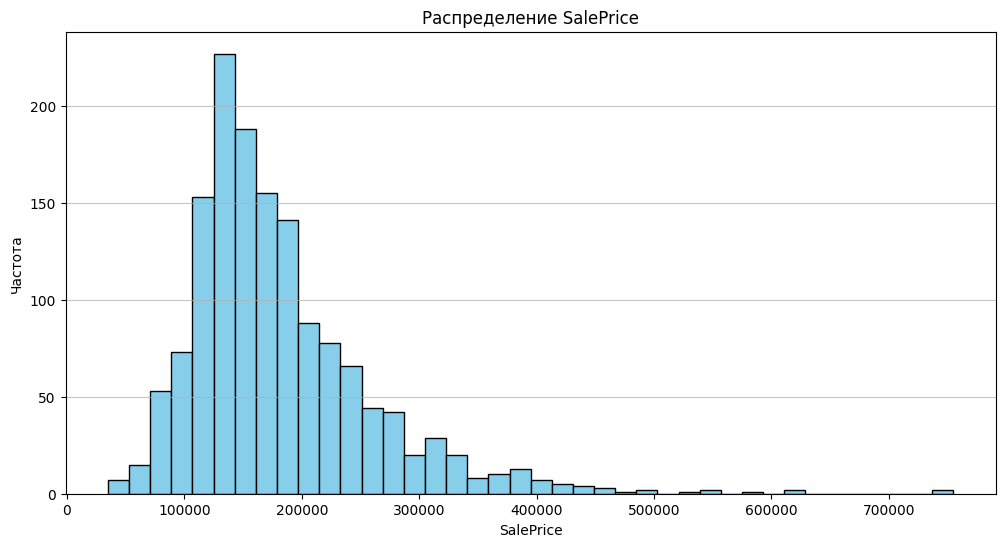

In [17]:
# Полная статистика по SalePrice
saleprice = df_corrected['SalePrice']

print("=== Описательные статистики (describe) ===")
display(saleprice.describe())  # count, mean, std, min, 25%, 50%, 75%, max

print("\n=== Стандартное отклонение ===")
print(saleprice.std())

print("\n=== Дисперсия ===")
print(saleprice.var())

print("\n=== Асимметрия (skewness) ===")
print(saleprice.skew())

print("\n=== Эксцесс (kurtosis) ===")
print(saleprice.kurtosis())

print("\n=== Мода (mode) ===")
print(saleprice.mode().values)

print("\n=== Перцентили (5th, 25th, 50th, 75th, 95th, 99th) ===")
percentiles = [0, 1, 5, 25, 50, 75, 95, 99, 100]
percentile_values = saleprice.quantile([p/100 for p in percentiles])
for p, v in zip(percentiles, percentile_values.values):
    print(f"{p}th percentile: {v}")

# Можно всё объединить в таблицу для просмотра:
stats = {
    "count": saleprice.count(),
    "mean": saleprice.mean(),
    "std": saleprice.std(),
    "variance": saleprice.var(),
    "min": saleprice.min(),
    "5%": saleprice.quantile(0.05),
    "25%": saleprice.quantile(0.25),
    "50% (median)": saleprice.median(),
    "75%": saleprice.quantile(0.75),
    "95%": saleprice.quantile(0.95),
    "99%": saleprice.quantile(0.99),
    "max": saleprice.max(),
    "mode": saleprice.mode().values[0] if not saleprice.mode().empty else None,
    "skewness": saleprice.skew(),
    "kurtosis": saleprice.kurtosis()
}
# Итоговая табличка в удобном и красивом формате
stats_df_saleprice = pd.DataFrame(stats, index=[0]).T
stats_df_saleprice.columns = ['SalePrice']
stats_df_saleprice = stats_df_saleprice.style.format("{:,.2f}").set_caption('Статистики переменной SalePrice')
display(stats_df_saleprice)

plt.figure(figsize=(12,6))
plt.hist(saleprice, bins=40, color='skyblue', edgecolor='black')
plt.title('Распределение SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.7)
plt.show()

# D) Фичи: Энкодинг и Инжиниринг (Feature Engineering)

Label Encoding + One Hot Encoding

In [18]:

# Определим категориальные признаки (тип object)
cat_columns = df_corrected.select_dtypes(include=['object']).columns

# Список качественных признаков -- по описанию и явным названиям
quality_mapping = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
}

quality_cols = [col for col in cat_columns if (
    'Qual' in col or
    'Cond' in col or
    'QC'   in col or
    col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
            'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']
)]

# Применяем маппинг к "качественным" колонкам
df_encoded = df_corrected.copy()
for col in quality_cols:
    df_encoded[col] = df_encoded[col].map(quality_mapping)
    df_encoded[col] = df_encoded[col].fillna(0).astype(int)

# Категориальные признаки, не являющиеся качественными
other_cat_columns = [col for col in cat_columns if col not in quality_cols]

# Применяем One Hot Encoding к остальным категориальным колонкам
df_encoded = pd.get_dummies(df_encoded, columns=other_cat_columns, drop_first=False)

# Повторно применим One Hot Encoding К ТОЛЬКО Condition1 и Condition2
df_encoded = pd.get_dummies(df_encoded, columns=['Condition1', 'Condition2'], drop_first=False)
display(df_encoded.head(10))
print(df_encoded.shape)

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,Fireplaces,FireplaceQu,GarageCars,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,MoSold,SaleCondition,SalePrice,HouseAge,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_NoVrn,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtExposure_Av,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtExposure_NoBasement,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_NoBasement,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_NoBasement,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_NoGarage,GarageFinish_Fin,GarageFinish_NoGarage,GarageFinish_RFn,GarageFinish_Unf,PavedDrive_N,PavedDrive_P,PavedDrive_Y,Fence_GdPrv,Fence_GdWo,Fence_MnPrv,Fence_MnWw,Fence_NoFence,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,Condition1_0,Condition2_0
0,1,60,65.0,8450,7,5,196.0,4,3,4,3,706,0,150,856,5,0,1710,1,0,2,1,3,1,4,0,0,2,3,3,0,61,0,0,0,2,0,208500,5,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,Fa

(1460, 222)


Feature Engineering. Объединим YearBuilt, YearRemodAdd, GarageYrBlt (c разными весами), так как эти параметры во многом связаны между собой.

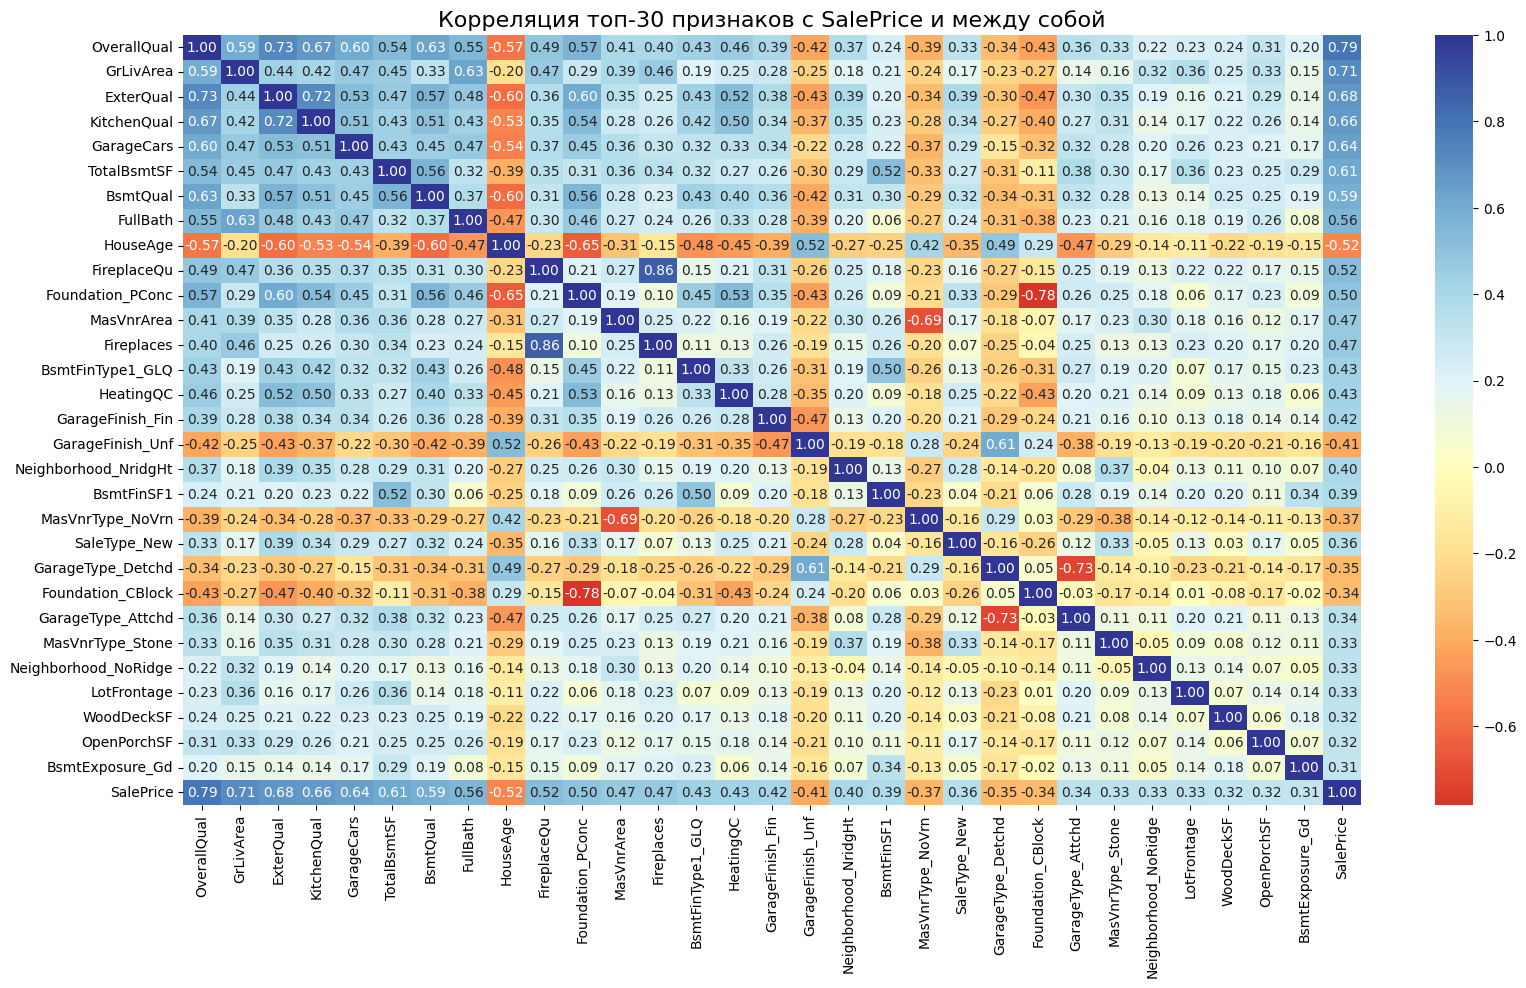

Оставлено признаков: 150
Из них признаков районов: 25

Удалённые признаки (информационный шум):
['3SsnPorch', 'BldgType_TwnhsE', 'BsmtExposure_Mn', 'BsmtFinSF2', 'BsmtFinType2_ALQ', 'BsmtFinType2_GLQ', 'BsmtFinType2_LwQ', 'BsmtFinType2_Rec', 'BsmtHalfBath', 'Condition1_0', 'Condition2_0', 'Electrical_FuseP', 'Electrical_Mix', 'ExterCond', 'Exterior1st_AsphShn', 'Exterior1st_BrkFace', 'Exterior1st_CBlock', 'Exterior1st_ImStucc', 'Exterior1st_Plywood', 'Exterior1st_Stone', 'Exterior1st_Stucco', 'Exterior2nd_AsphShn', 'Exterior2nd_Brk Cmn', 'Exterior2nd_BrkFace', 'Exterior2nd_CBlock', 'Exterior2nd_Other', 'Exterior2nd_Stone', 'Exterior2nd_Stucco', 'Exterior2nd_Wd Shng', 'Fence_GdPrv', 'Foundation_Stone', 'Foundation_Wood', 'Functional_Maj1', 'Functional_Mod', 'Functional_Sev', 'GarageType_2Types', 'GarageType_Basment', 'Heating_Floor', 'Heating_GasW', 'Heating_OthW', 'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_SLvl', 'Id', 'LandContour_Low', 'LandContour_Lvl', 'LandSlope_Mod', '

In [19]:
# 1. Посчитаем матрицу корреляций
corr_matrix = df_encoded.corr(numeric_only=True)

# 2. Визуализация топ-30 признаков (оставляем как есть для анализа)
top_corr = corr_matrix['SalePrice'].abs().sort_values(ascending=False).iloc[1:31]
top_features = top_corr.index

plt.figure(figsize=(19,10))
sns.heatmap(df_encoded[top_features.tolist() + ['SalePrice']].corr(), annot=True, fmt=".2f", cmap="RdYlBu", center=0)
plt.title("Корреляция топ-30 признаков с SalePrice и между собой", fontsize=16)
plt.show()

# 3. ЛОГИКА ОТБОРА: Корреляция >= 0.3 ИЛИ это признак района (Neighborhood)
corr_with_saleprice = corr_matrix['SalePrice'].abs()

# Признаки с высокой корреляцией
strong_features = corr_with_saleprice[corr_with_saleprice >= 0.05].index.tolist()

# Все признаки районов (даже если у них корреляция < 0.3)
neighborhood_features = [col for col in df_encoded.columns if col.startswith('Neighborhood_')]

# Объединяем списки (используем set, чтобы не было дублей, если какой-то район и так имел корреляцию > 0.3)
cols_to_keep = list(set(strong_features + neighborhood_features))

# Создаем отфильтрованный датасет
df_encoded_filtered = df_encoded[cols_to_keep]

print(f"Оставлено признаков: {df_encoded_filtered.shape[1]}")
print(f"Из них признаков районов: {len(neighborhood_features)}")

# 4. Определим удалённые признаки
removed_cols = set(df_encoded.columns) - set(df_encoded_filtered.columns)
print("\nУдалённые признаки (информационный шум):")
print(sorted(list(removed_cols)))
df_ready=df_encoded_filtered

# E) Визуализация 

Распределение: гистограммы.

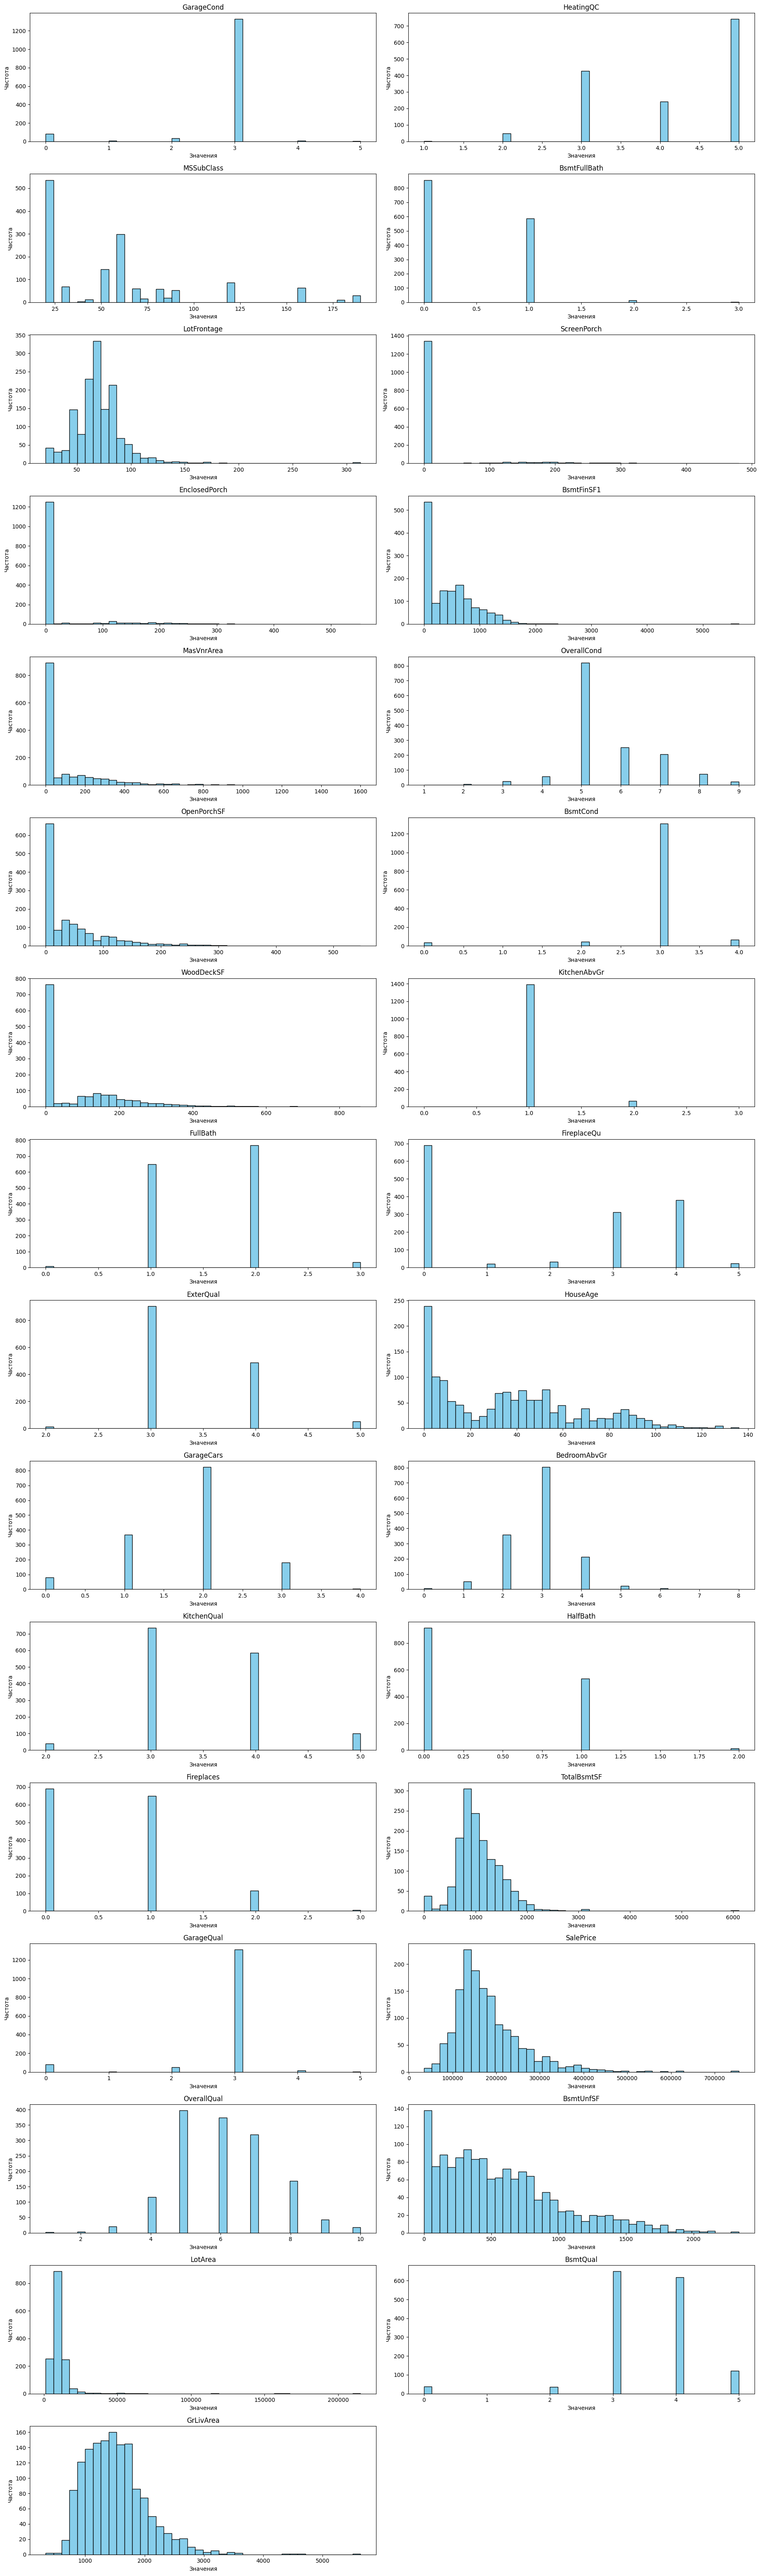

In [20]:
# Нарисуем распределения признаков, оставшихся после фильтрации по корреляции
num_cols = df_ready.select_dtypes(include=['int64', 'float64']).columns
n_cols = 2
n_rows = (len(num_cols) + 1) // n_cols

plt.figure(figsize=(19, n_rows * 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    plt.hist(df_ready[col].dropna(), bins=40, color='skyblue', edgecolor='k')
    plt.title(col)
    plt.xlabel('Значения')
    plt.ylabel('Частота')
plt.tight_layout()



In [21]:
#найдем эту точку
display(df_ready[(df_ready['SalePrice'] == 160000) & (df_ready['TotalBsmtSF'] == 6110)])
#посмотрим максимумы по интересующим нас параметрам
display(df_ready[['SalePrice', 'TotalBsmtSF']].max())

,BldgType_Twnhs,GarageCond,CentralAir_N,HeatingQC,LandContour_HLS,BsmtFinType1_GLQ,GarageFinish_NoGarage,GarageFinish_RFn,Neighborhood_NoRidge,CentralAir_Y,Exterior2nd_VinylSd,Exterior1st_VinylSd,MSZoning_FV,MasVnrType_BrkFace,HouseStyle_2Story,MSZoning_RH,Functional_Maj2,Neighborhood_Blueste,Neighborhood_SWISU,BsmtFinType1_ALQ,Neighborhood_Mitchel,Exterior2nd_AsbShng,Functional_Min1,Fence_NoFence,PavedDrive_Y,MSSubClass,BsmtFullBath,Heating_Wall,LotFrontage,ScreenPorch,Exterior2nd_HdBoard,LandSlope_Gtl,EnclosedPorch,BsmtFinSF1,GarageFinish_Unf,MasVnrArea,MSZoning_RM,OverallCond,OpenPorchSF,Exterior1st_MetalSd,Foundation_Slab,HouseStyle_1.5Fin,Neighborhood_Somerst,BsmtFinType2_Unf,GarageType_Attchd,PavedDrive_N,Neighborhood_BrDale,Exterior2nd_Wd Sdng,Fence_MnWw,BsmtCond,WoodDeckSF,KitchenAbvGr,SaleType_WD,FullBath,FireplaceQu,Neighborhood_MeadowV,Exterior2nd_ImStucc,Neighborhood_Edwards,LotConfig_Inside,BsmtExposure_No,Exterior1st_Wd Sdng,Electrical_SBrkr,HouseStyle_SFoyer,ExterQual,Neighborhood_IDOTRR,Exterior2nd_MetalSd,Exterior2nd_CmentBd,BldgType_1Fam,Foundation_PConc,Fence_MnPrv,Neighborhood_OldTown,HouseAge,Heating_Grav,Exterior1st_HdBoard,GarageType_NoGarage,Neighborhood_Blmngtn,BldgType_2fmCon,Neighborhood_Gilbert,Foundation_BrkTil,Exterior1st_AsbShng,LotConfig_CulDSac,BsmtExposure_NoBasement,Neighborhood_CollgCr,Functional_Min2,BsmtFinType2_BLQ,GarageCars,LandContour_Bnk,Neighborhood_ClearCr,HouseStyle_1Story,Exterior1st_BrkComm,RoofMatl_WdShngl,MasVnrType_Stone,Neighborhood_NridgHt,MSZoning_C (all),PavedDrive_P,Electrical_FuseA,BsmtFinType1_NoBasement,GarageType_CarPort,BldgType_Duplex,Neighborhood_Timber,Electrical_FuseF,Heating_GasA,RoofStyle_Hip,BedroomAbvGr,BsmtFinType1_LwQ,HouseStyle_1.5Unf,RoofStyle_Gable,KitchenQual,Exterior1st_CemntBd,BsmtExposure_Av,HalfBath,GarageType_BuiltIn,BsmtFinType1_Rec,BsmtFinType1_BLQ,BsmtFinType2_NoBasement,SaleType_COD,Exterior2nd_Plywood,Fireplaces,SaleType_New,LotShape_IR2,MSZoning_RL,Functional_Typ,BsmtExposure_Gd,TotalBsmtSF,Fence_GdWo,Neighborhood_BrkSide,RoofMatl_CompShg,Neighborhood_StoneBr,Neighborhood_Sawyer,Neighborhood_NAmes,Neighborhood_Crawfor,BsmtFinType1_Unf,GarageQual,Neighborhood_SawyerW,SalePrice,Foundation_CBlock,OverallQual,Exterior1st_WdShing,LotShape_IR1,Neighborhood_NWAmes,Neighborhood_Veenker,BsmtUnfSF,Neighborhood_NPkVill,LotShape_Reg,LotArea,BsmtQual,GrLivArea,GarageFinish_Fin,GarageType_Detchd,MasVnrType_NoVrn
1298,False,3,False,5,False,True,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,True,60,2,False,313.0,0,False,True,0,5644,False,796.0,False,5,292,False,False,False,False,True,True,False,False,False,False,3,214,1,False,2,4,False,False,True,False,False,False,True,False,5,False,False,False,True,True,False,False,0,False,False,False,False,False,False,False,False,False,False,False,False,False,2,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,3,False,False,False,5,False,False,1,False,False,False,False,False,False,3,True,False,True,True,True,6110,False,False,False,False,False,False,False,False,3,False,160000,False,10,False,False,False,False,466,False,False,63887,5,5642,True,False,False


SalePrice      755000
TotalBsmtSF      6110
dtype: int64

Видно, что это реальный особняк, т.е не ошибка,и он причем соответствует максимуму показателя по всем данным. Тем не менее, удивительно, что цена в примерно в 5 раз меньше максимума. Разберемся.

In [22]:
# дополнительно возьмем эту строчку прямо из первого датасета df и извлечем столбец SaleCondition, чтобы понять специфичность сделки
display(df[(df['SalePrice'] == 160000) & (df['TotalBsmtSF'] == 6110)]['SaleCondition'])

1298    Partial
Name: SaleCondition, dtype: str

SaleCondition = **Partial**, значит сделка - непростая. 
Скорее всего, продается не готовый дом, а либо:

- Объект на этапе строительства (продажа с дисконтом под завершение)
- Частичная продажа долей/этапов строительства
- Сделка, где цена отражает только часть работ

TotalBsmtSF такой большой потому, что туда скорее всего вошла площадь фундамента/котлована/недостроенная площадь дома вообще.

Для построенияы модели эти данные не подходят, так как в датасете df_ready особые сделки не учитываются. Удалим эту запись.

In [23]:
df_ready = df_ready[~((df_ready['SalePrice'] == 160000) & (df_ready['TotalBsmtSF'] == 6110))]

PS. до этого уже рисовал разнообразные графики, в т.ч. bar plots и correlation heatmaps.

# F) Итоговые выводы

=== СТАТИСТИЧЕСКИЕ МЕТРИКИ ===
R2 score (Коэффициент детерминации):      0.9343
Adjusted R2 (Скорректированный R2):       0.8653

=== ФИНАНСОВЫЕ МЕТРИКИ (Ошибки в долларах) ===
MAE (Средняя абсолютная ошибка):          $13,876
MedAE (Медианная абсолютная ошибка):      $9,785
RMSE (Корень из среднеквадратичной):      $19,169

=== ОТНОСИТЕЛЬНЫЕ МЕТРИКИ ===
MAPE (Средняя процентная ошибка):         8.54%
RMSE Log (Метрика Kaggle):                0.1205

Всего признаков подано: 149
Отобрано Lasso (ненулевой вес): 81


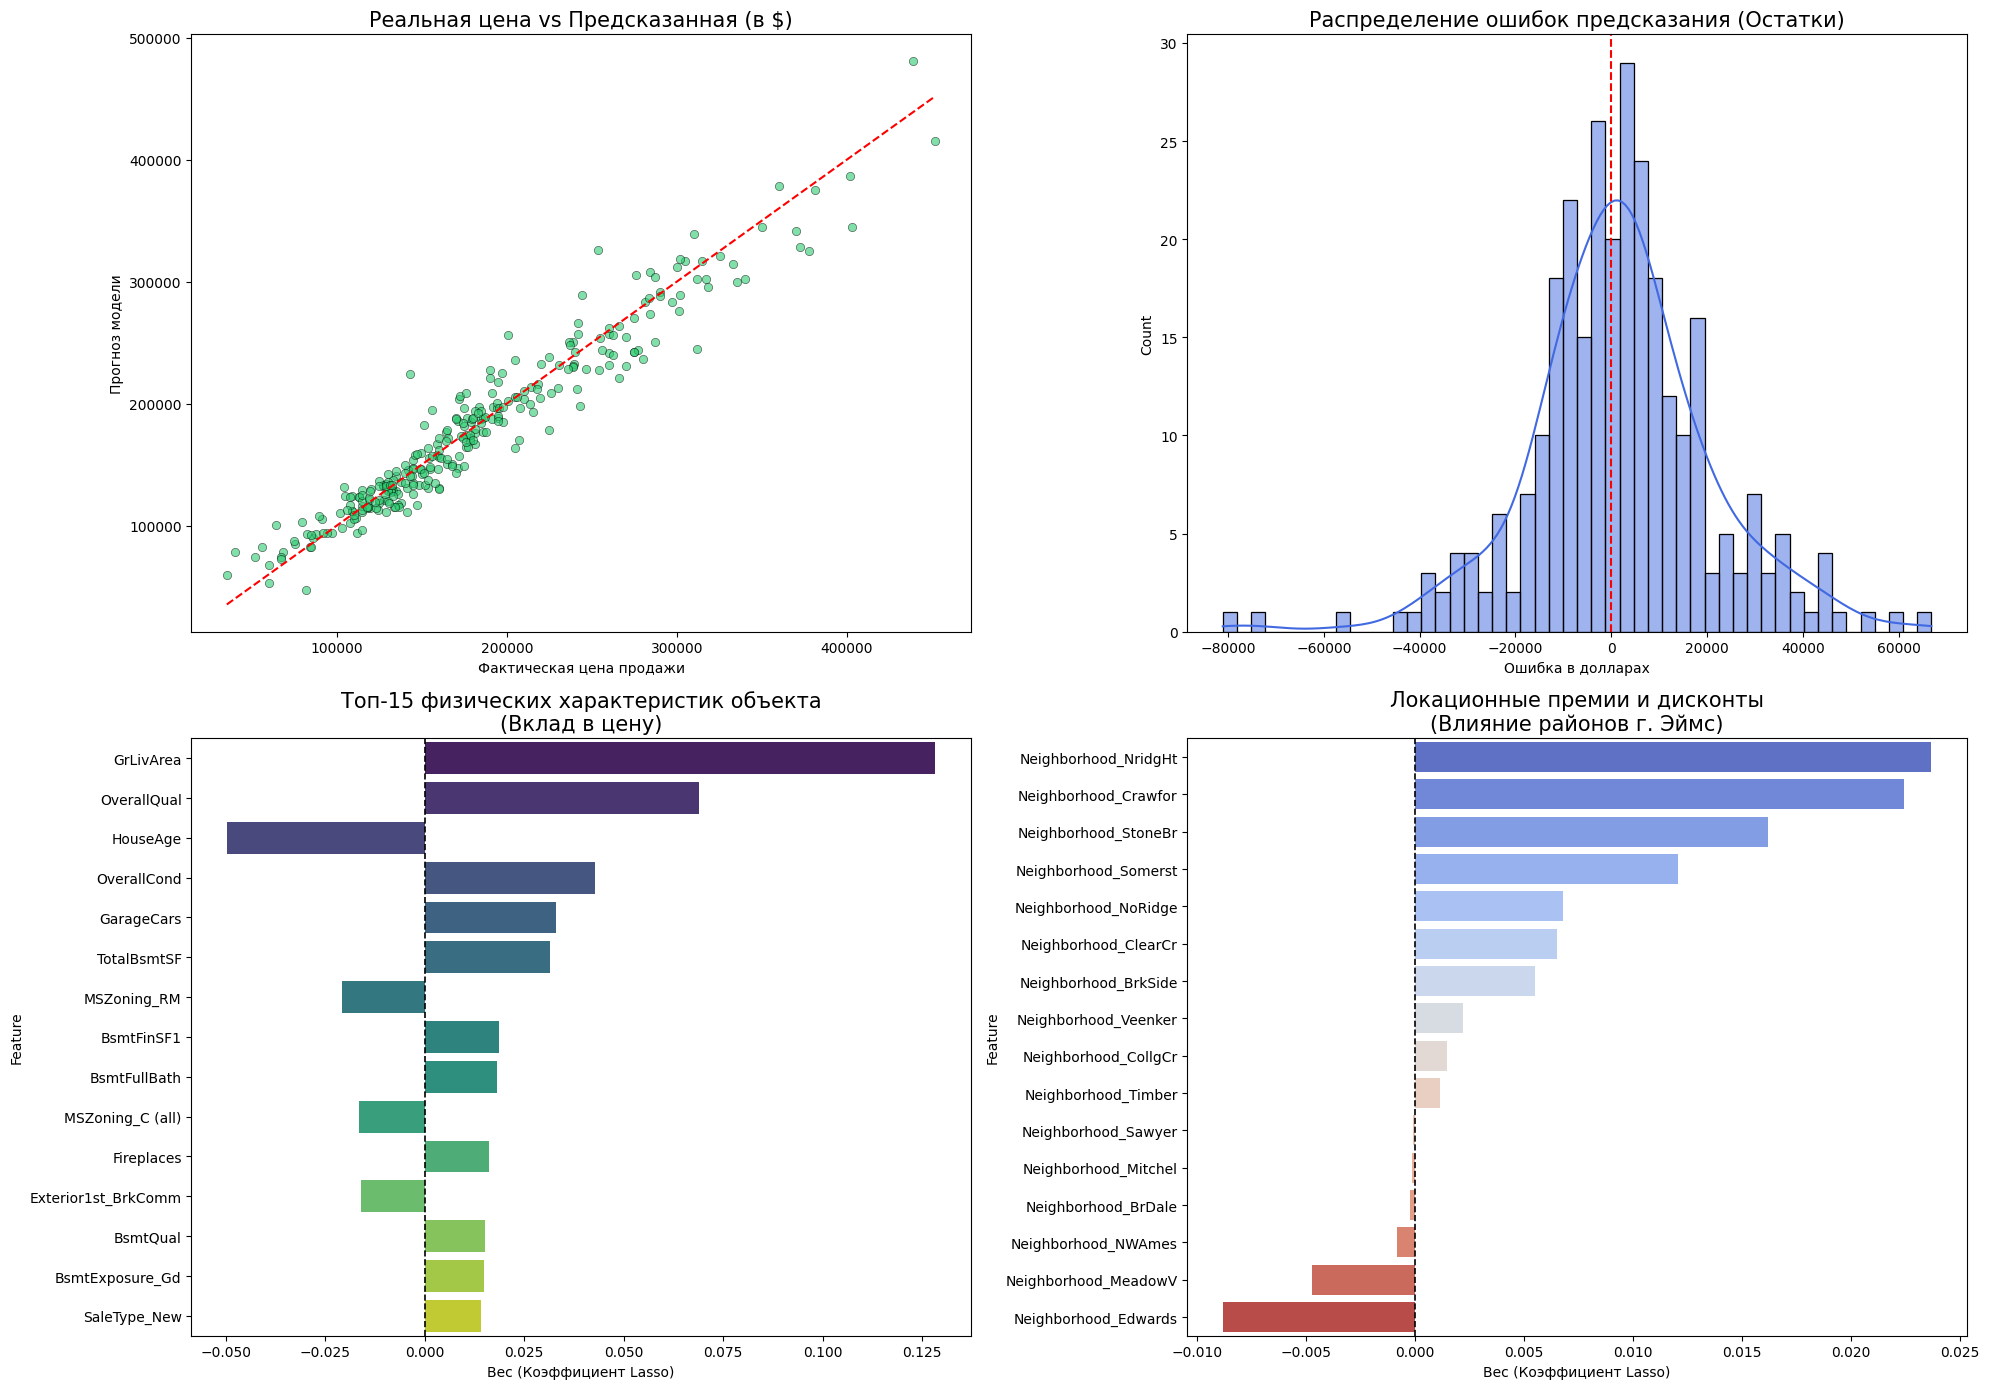



--- ГРАФИКИ С ИНТЕРПРЕТИРУЕМЫМИ КОЭФФИЦИЕНТАМИ (ПОЛУЭЛАСТИЧНОСТЬ) ---


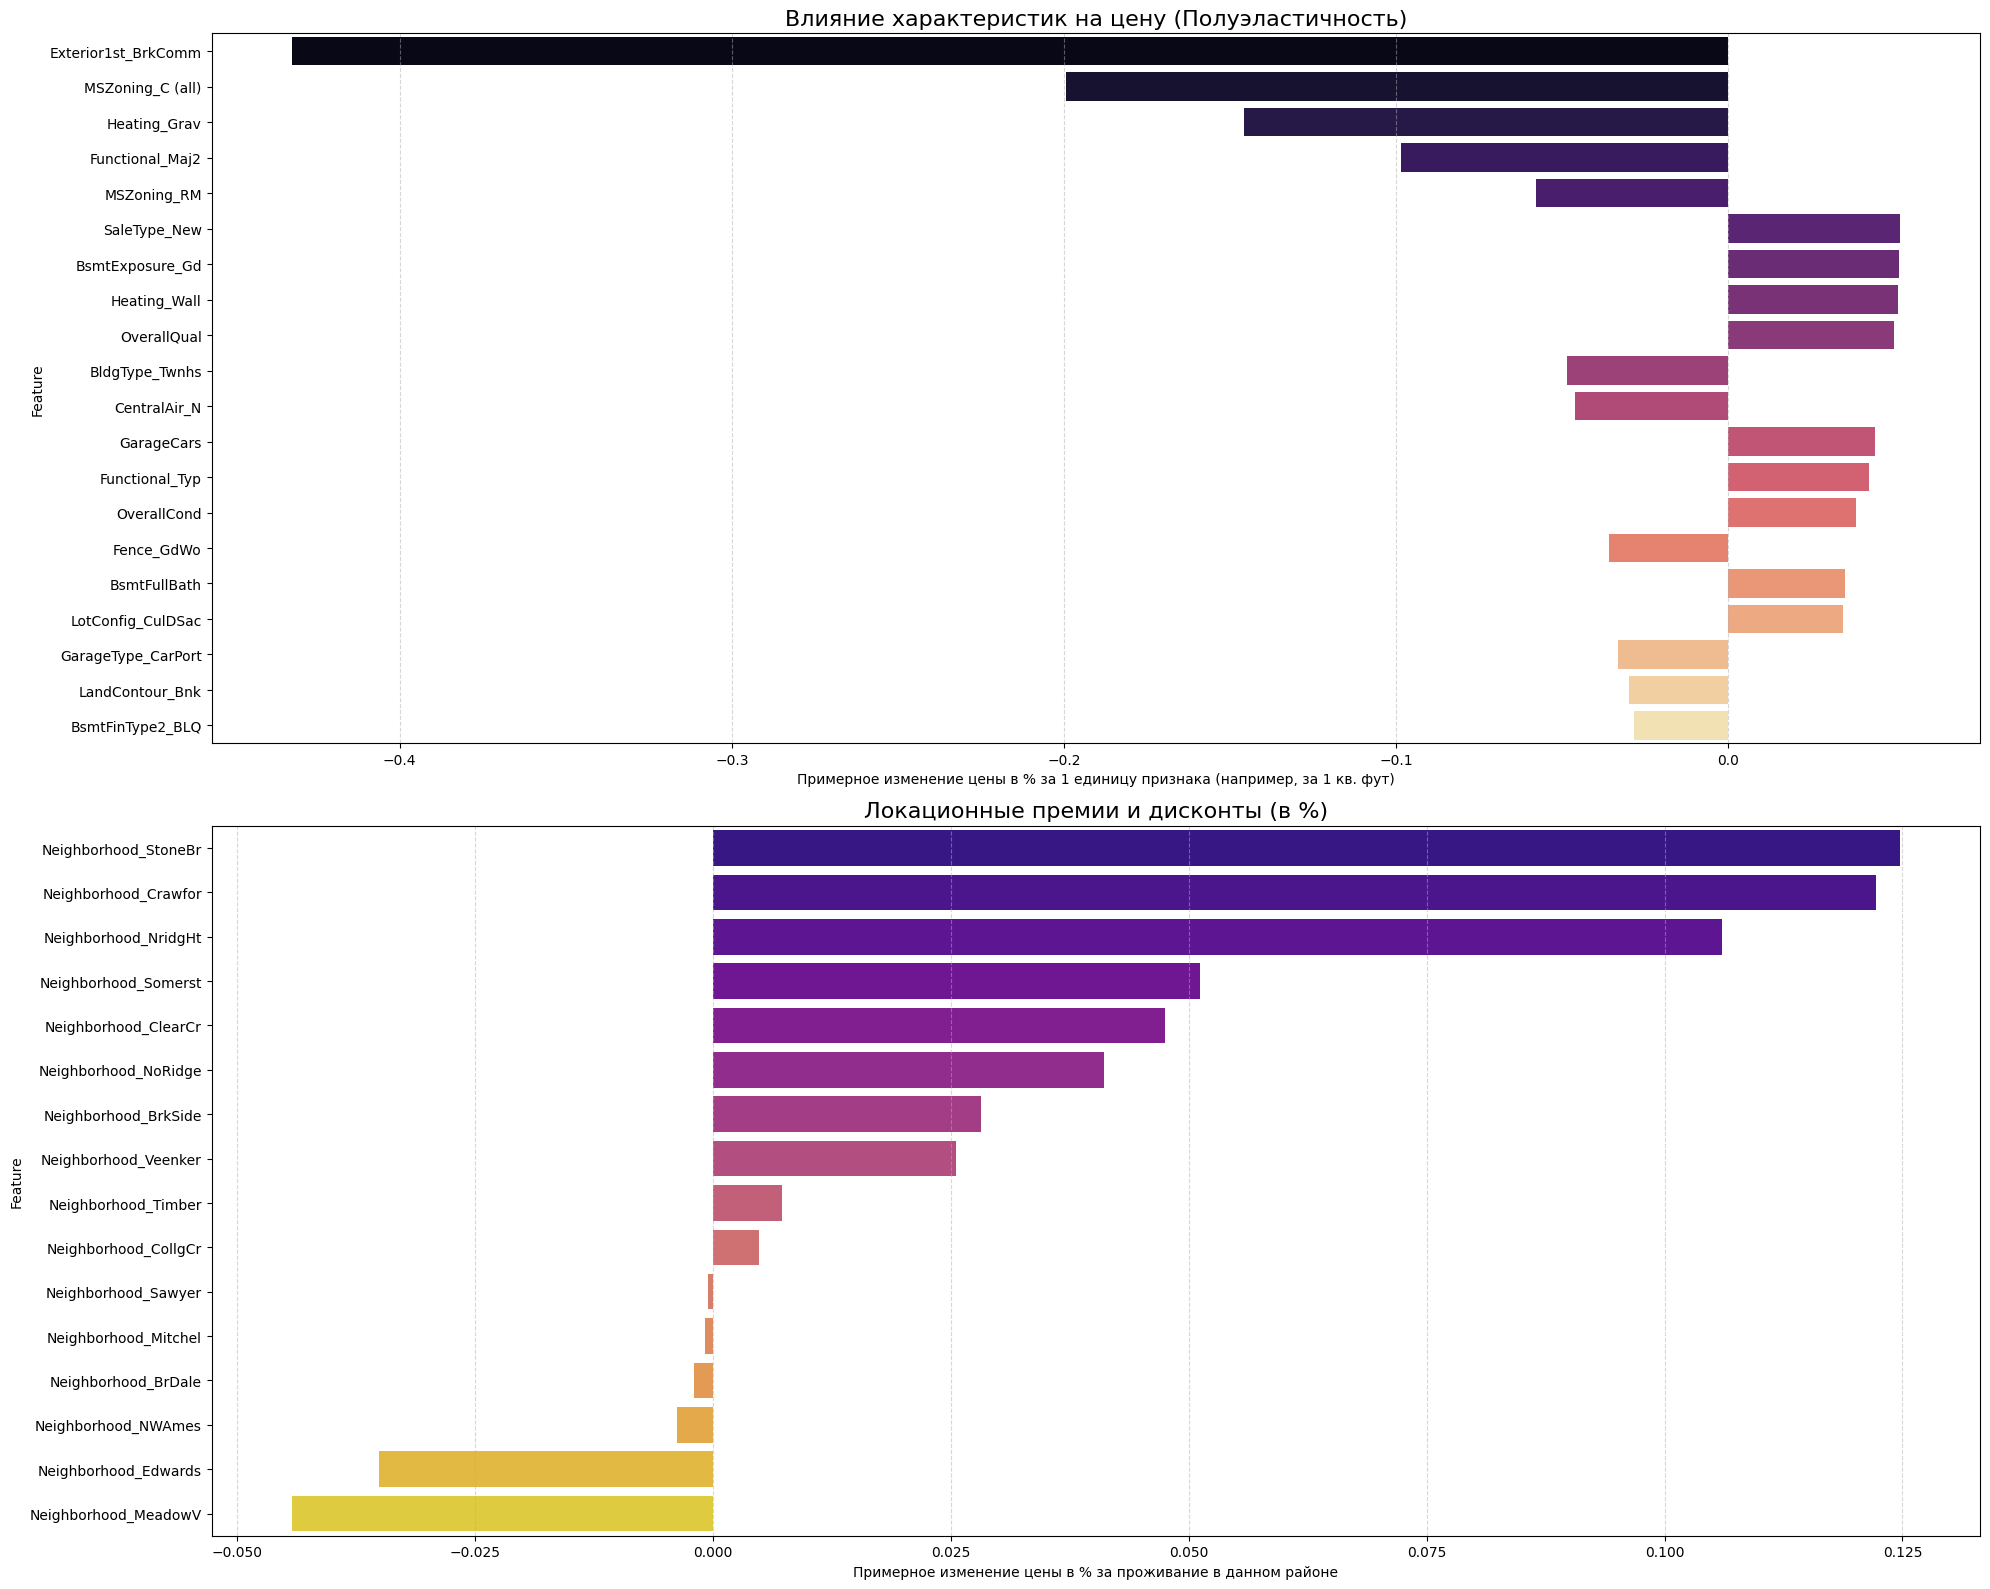

,Метрика,Значение
0,R2 score (Коэффициент детерминации),0.9343 (93.43%)
1,Adjusted R2 (Скорректированный R2),0.8653 (86.53%)
2,MAE (Средняя абсолютная ошибка),"$13,876"
3,MedAE (Медианная абсолютная ошибка),"$9,785"
4,RMSE (Корень из среднеквадратичной),"$19,169"
5,MAPE (Средняя процентная ошибка),8.54%
6,RMSE Log (Метрика Kaggle),0.1205


In [30]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, median_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. ФИНАЛЬНАЯ ПОДГОТОВКА И ОЧИСТКА
# ==========================================

# Сначала заполняем пропуски (чтобы в X точно не попали NaN)
df_ready = df_ready.fillna(df_ready.median())

# Отделяем признаки (X) и целевую переменную (y)
X = df_ready.drop(columns=['SalePrice'], errors='ignore')
if 'Id' in X.columns:
    X = X.drop(columns=['Id'])

# ЛОГАРИФМИРУЕМ цену (lnP) для лог-линейной модели
y = np.log1p(df_ready['SalePrice']) 

# МАСШТАБИРОВАНИЕ (Z-стандартизация для адекватных весов)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) # Возвращаем названия колонок

# Разделяем на обучающую и валидационную выборки (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# ==========================================
# 2. ПОСТРОЕНИЕ МОДЕЛИ LASSO
# ==========================================

lasso = Lasso(alpha=0.0028, random_state=42)
lasso.fit(X_train, y_train)

# Делаем предсказания
y_pred_log = lasso.predict(X_test)
y_pred_real = np.expm1(y_pred_log) # Возвращаем в доллары
y_test_real = np.expm1(y_test)

# ==========================================
# 3. РАСШИРЕННАЯ ОЦЕНКА КАЧЕСТВА
# ==========================================

r2 = r2_score(y_test_real, y_pred_real)
n = X_test.shape[0] 
p = X_test.shape[1] 
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("=== СТАТИСТИЧЕСКИЕ МЕТРИКИ ===")
print(f"R2 score (Коэффициент детерминации):      {r2:.4f}")
print(f"Adjusted R2 (Скорректированный R2):       {adj_r2:.4f}")

print("\n=== ФИНАНСОВЫЕ МЕТРИКИ (Ошибки в долларах) ===")
print(f"MAE (Средняя абсолютная ошибка):          ${mean_absolute_error(y_test_real, y_pred_real):,.0f}")
print(f"MedAE (Медианная абсолютная ошибка):      ${median_absolute_error(y_test_real, y_pred_real):,.0f}")
print(f"RMSE (Корень из среднеквадратичной):      ${np.sqrt(mean_squared_error(y_test_real, y_pred_real)):,.0f}")

print("\n=== ОТНОСИТЕЛЬНЫЕ МЕТРИКИ ===")
print(f"MAPE (Средняя процентная ошибка):         {mean_absolute_percentage_error(y_test_real, y_pred_real)*100:.2f}%")
print(f"RMSE Log (Метрика Kaggle):                {np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}")

# ==========================================
# 4. АНАЛИЗ ВЕСОВ И ЭКОНОМИЧЕСКАЯ ИНТЕРПРЕТАЦИЯ
# ==========================================

weights = pd.DataFrame({
    'Feature': X.columns,
    'Weight': lasso.coef_
})

# Оставляем только те признаки, которые Lasso НЕ обнулила
active_weights = weights[weights['Weight'] != 0].copy()

# Разделяем на районы и физические характеристики
neigh_weights = active_weights[active_weights['Feature'].str.contains('Neighborhood')].sort_values(by='Weight', ascending=False)
other_weights = active_weights[~active_weights['Feature'].str.contains('Neighborhood')].assign(abs_w=active_weights['Weight'].abs()).sort_values(by='abs_w', ascending=False).head(15)

print(f"\nВсего признаков подано: {X.shape[1]}")
print(f"Отобрано Lasso (ненулевой вес): {len(active_weights)}")

# ==========================================
# 5. КОМПЛЕКСНАЯ ВИЗУАЛИЗАЦИЯ
# ==========================================

plt.figure(figsize=(20, 14))

# График 1: Реальные цены vs Предсказанные
plt.subplot(2, 2, 1)
sns.scatterplot(x=y_test_real, y=y_pred_real, alpha=0.6, color='#2ecc71', edgecolor='k')
plt.plot([y_test_real.min(), y_test_real.max()],[y_test_real.min(), y_test_real.max()], color='red', linestyle='--')
plt.title('Реальная цена vs Предсказанная (в $)', fontsize=15)
plt.xlabel('Фактическая цена продажи')
plt.ylabel('Прогноз модели')

# График 2: Распределение остатков
plt.subplot(2, 2, 2)
residuals = y_test_real - y_pred_real
sns.histplot(residuals, kde=True, color='royalblue', bins=50)
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Распределение ошибок предсказания (Остатки)', fontsize=15)
plt.xlabel('Ошибка в долларах')

# График 3: Физические характеристики
plt.subplot(2, 2, 3)
sns.barplot(data=other_weights, x='Weight', y='Feature', palette='viridis')
plt.axvline(x=0, color='black', lw=1.2, linestyle='--')
plt.title('Топ-15 физических характеристик объекта\n(Вклад в цену)', fontsize=15)
plt.xlabel('Вес (Коэффициент Lasso)')

# График 4: Локация (Районы)
plt.subplot(2, 2, 4)
sns.barplot(data=neigh_weights, x='Weight', y='Feature', palette='coolwarm')
plt.axvline(x=0, color='black', lw=1.2, linestyle='--')
plt.title('Локационные премии и дисконты\n(Влияние районов г. Эймс)', fontsize=15)
plt.xlabel('Вес (Коэффициент Lasso)')

plt.tight_layout()
plt.show()

# ==========================================
# 4B. КОНВЕРТАЦИЯ ВЕСОВ В ИНТЕРПРЕТИРУЕМЫЕ ЕДИНИЦЫ (ПОЛУЭЛАСТИЧНОСТЬ)
# ==========================================

# Формула: coef_unscaled = coef_scaled / standard_deviation
# scaler.scale_ как раз хранит стандартные отклонения для каждого признака
unscaled_coefs = lasso.coef_ / scaler.scale_

# Создаем DataFrame с "человеческими" весами
unscaled_weights = pd.DataFrame({
    'Feature': X.columns,
    'Unscaled_Weight': unscaled_coefs
})

# Оставляем только активные (не обнуленные Lasso)
active_unscaled_weights = unscaled_weights[unscaled_weights['Unscaled_Weight'] != 0].copy()

# Разделяем на районы и прочее
unscaled_neigh = active_unscaled_weights[active_unscaled_weights['Feature'].str.contains('Neighborhood')]
unscaled_other = active_unscaled_weights[~active_unscaled_weights['Feature'].str.contains('Neighborhood')]

# Сортируем для красивого графика
unscaled_other = unscaled_other.assign(abs_w=unscaled_other['Unscaled_Weight'].abs()).sort_values('abs_w', ascending=False).head(20)
unscaled_neigh = unscaled_neigh.sort_values('Unscaled_Weight', ascending=False)

# ==========================================
# 5B. ВИЗУАЛИЗАЦИЯ ИНТЕРПРЕТИРУЕМЫХ ВЕСОВ
# ==========================================

print("\n\n--- ГРАФИКИ С ИНТЕРПРЕТИРУЕМЫМИ КОЭФФИЦИЕНТАМИ (ПОЛУЭЛАСТИЧНОСТЬ) ---")

plt.figure(figsize=(20, 16))

# График 1: Физические характеристики в единицах измерения
plt.subplot(2, 1, 1)
sns.barplot(data=unscaled_other, x='Unscaled_Weight', y='Feature', palette='magma')
plt.title('Влияние характеристик на цену (Полуэластичность)', fontsize=16)
plt.xlabel('Примерное изменение цены в % за 1 единицу признака (например, за 1 кв. фут)')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# График 2: Районы в процентах
plt.subplot(2, 1, 2)
sns.barplot(data=unscaled_neigh, x='Unscaled_Weight', y='Feature', palette='plasma')
plt.title('Локационные премии и дисконты (в %)', fontsize=16)
plt.xlabel('Примерное изменение цены в % за проживание в данном районе')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

error_stats = pd.DataFrame({
    "Метрика": [
        "R2 score (Коэффициент детерминации)", 
        "Adjusted R2 (Скорректированный R2)", 
        "MAE (Средняя абсолютная ошибка)", 
        "MedAE (Медианная абсолютная ошибка)", 
        "RMSE (Корень из среднеквадратичной)", 
        "MAPE (Средняя процентная ошибка)",
        "RMSE Log (Метрика Kaggle)"
   
    ],
    "Значение": [
        f"{r2:.4f} ({r2*100:.2f}%)",
        f"{adj_r2:.4f} ({adj_r2*100:.2f}%)",
        f"${mean_absolute_error(y_test_real, y_pred_real):,.0f}",
        f"${median_absolute_error(y_test_real, y_pred_real):,.0f}",
        f"${np.sqrt(mean_squared_error(y_test_real, y_pred_real)):,.0f}",
        f"{mean_absolute_percentage_error(y_test_real, y_pred_real)*100:.2f}%",
        f"{np.sqrt(mean_squared_error(y_test, y_pred_log)):.4f}"
    ]
})

display(error_stats)




In [29]:
# 1. Получаем медианную цену дома для расчета долларового вклада
median_price = np.expm1(y).median()

# 2. Собираем все коэффициенты в одну таблицу
comparison_table = pd.DataFrame({
    'Признак': X.columns,
    # 1. Лассо-веса (масштабированные) - показывают ОТНОСИТЕЛЬНУЮ ВАЖНОСТЬ
    'Стандартиз. полуэластичность': lasso.coef_,
    # 2. Полуэластичность (лог. веса) - показывают % ИЗМЕНЕНИЯ ЦЕНЫ за 1 ед. признака
    'Полуэластичность': (lasso.coef_ / scaler.scale_) * 100
})

# 3. Рассчитываем аддитивный вес (в долларах) для типичного (медианного) дома
# Формула: Цена * (exp(коэффициент) - 1)
comparison_table['Прибавка к цене'] = comparison_table['Полуэластичность'] / 100 * median_price

# 4. Отбираем Топ-15 самых влиятельных факторов (по абсолютному масштабированному весу)
comparison_table['abs_weight'] = comparison_table['Стандартиз. полуэластичность'].abs()
top_15_comparison = comparison_table.sort_values(by='abs_weight', ascending=False).head(15).copy()
# Перевод топ-15 признаков на русский вручную
rus_features = {
    'GrLivArea': 'Жилая площадь (кв. футы)',
    'OverallQual': 'Оценка материала и отделки дома',
    'HouseAge': 'Возраст дома',
    'OverallCond': 'Оценка общего состояния дома',
    'GarageCars': 'Количество машиномест',
    'TotalBsmtSF': 'Общая площадь подвала (кв. футы)',
    'Neighborhood_NridgHt': 'Район: Northridge Heights',
    'Neighborhood_StoneBr': 'Район: Stone Brook',
    'KitchenQual': 'Качество кухни',
    '1stFlrSF': 'Площадь 1 этажа (кв. футы)',
    'Neighborhood_noRidge': 'Район: Northridge',
    'BsmtFinSF1': 'Площадь готового подвала (кв. футы)',
    'Neighborhood_OldTown': 'Район: Old Town',
    'LotArea': 'Площадь участка (кв. футы)',
    'Exterior1st_BrkComm': 'Внешняя отделка: кирпич',
    'BsmtFullBath': 'Количество полноценных ванных в подвале',
    'MSZoning_C (all)': 'Зонирование: Коммерческое',
    'Fireplaces': 'Количество каминов',
    'MSZoning_RM': 'Зонирование: Многоквартирное',
    'Neighborhood_Crawfor': 'Район: Crawford'
}

# Заменяем названия ('Признак') в топ-15, если есть перевод
top_15_comparison['Перевод признака'] = top_15_comparison['Признак'].map(rus_features).fillna('')

# Удаляем вспомогательную колонку и наводим красоту
top_15_comparison.drop(columns='abs_weight', inplace=True)

# Округление для удобства чтения в курсовой
top_15_comparison['Стандартиз. полуэластичность'] = top_15_comparison['Стандартиз. полуэластичность'].round(4)
top_15_comparison['Полуэластичность'] = top_15_comparison['Полуэластичность'].round(3).map('{:,.3f}%'.format)
top_15_comparison['Прибавка к цене'] = top_15_comparison['Прибавка к цене'].round(0).map('${:,.0f}'.format)

# Вставим строку примечания в начало табл
# Представим стандартиз. полуэластичность в процентах
top_15_comparison['Стандартиз. полуэластичность'] = (top_15_comparison['Стандартиз. полуэластичность'] * 100).round(3).map('{:,.3f}%'.format)

display(top_15_comparison)


,Признак,Стандартиз. полуэластичность,Полуэластичность,Прибавка к цене,Перевод признака
145,GrLivArea,12.580%,0.024%,$40,Жилая площадь (кв. футы)
135,OverallQual,6.950%,5.038%,"$8,212",Оценка материала и отделки дома
71,HouseAge,-4.840%,-0.160%,$-261,Возраст дома
37,OverallCond,4.340%,3.903%,"$6,362",Оценка общего состояния дома
85,GarageCars,3.660%,4.900%,"$7,988",Количество машиномест
123,TotalBsmtSF,2.830%,0.007%,$11,Общая площадь подвала (кв. футы)
92,Neighborhood_NridgHt,2.460%,10.988%,"$17,910",Район: Northridge Heights
130,Neighborhood_Crawfor,2.330%,12.676%,"$20,662",Район: Crawford
36,MSZoning_RM,-2.020%,-5.671%,"$-9,244",Зонирование: Многоквартирное
117,Fireplaces,1.910%,2.971%,"$4,844",Количество каминов


In [26]:
# Составим таблицу топ-15 районов по абсолютному масштабу стандартизированной полуэластичности

# Выберем только районные признаки
neighborhood_feats = [col for col in comparison_table['Признак'] if col.startswith('Neighborhood_')]

# Отбираем топ-15 важнейших районов
top_15_neigh = comparison_table[comparison_table['Признак'].isin(neighborhood_feats)].copy()
top_15_neigh['abs_weight'] = top_15_neigh['Стандартиз. полуэластичность'].abs()
top_15_neigh = top_15_neigh.sort_values(by='abs_weight', ascending=False).head(15).copy()


    # Словарь для перевода признаков районов на русский язык
rus_neigh = {
     'Neighborhood_NridgHt': 'Район: Northridge Heights',
        'Neighborhood_StoneBr': 'Район: Stone Brook',
        'Neighborhood_Crawfor': 'Район: Crawford',
        'Neighborhood_NoRidge': 'Район: Northridge',
        'Neighborhood_Somerst': 'Район: Somerset',
        'Neighborhood_OldTown': 'Район: Old Town',
        'Neighborhood_BrkSide': 'Район: Brookside',
        'Neighborhood_SawyerW': 'Район: Sawyer West',
        'Neighborhood_NWAmes': 'Район: Northwest Ames',
        'Neighborhood_Sawyer': 'Район: Sawyer',
        'Neighborhood_CollgCr': 'Район: College Creek',
        'Neighborhood_Blueste': 'Район: Bluestem',
        'Neighborhood_Swisu': 'Район: Southwest Iowa State University',
        'Neighborhood_ClearCr': 'Район: Clear Creek',
        'Neighborhood_MeadowV': 'Район: Meadow Village',
        'Neighborhood_Edwards': 'Район: Edwards',
        'Neighborhood_Veenker': 'Район: Veenker',
        'Neighborhood_Timber': 'Район: Timber',
        'Neighborhood_BrDale': 'Район: Briardale',
        'Neighborhood_Mitchel': 'Район: Mitchel',
        # дополняйте при необходимости
}


# Делаем переведенные районы первым столбцом и убираем переводы из других столбцов
top_15_neigh['Район (перевод)'] = top_15_neigh['Признак'].map(rus_neigh).fillna('')
cols = top_15_neigh.columns.tolist()
# Переместим переведенный район в начало, убираем колонку 'Перевод признака', если есть
if 'Перевод признака' in cols:
    cols.remove('Перевод признака')
cols.insert(0, 'Район (перевод)')
top_15_neigh = top_15_neigh[cols]

# Добавим колонку с переводом района
top_15_neigh['Перевод признака'] = top_15_neigh['Признак'].map(rus_neigh).fillna('')

# Удаляем вспомогательную колонку
top_15_neigh.drop(columns='abs_weight', inplace=True)

# Округление и преобразование, аналогично основной таблице
top_15_neigh['Стандартиз. полуэластичность'] = (top_15_neigh['Стандартиз. полуэластичность'] * 100).round(3).map('{:,.3f}%'.format)
top_15_neigh['Полуэластичность'] = top_15_neigh['Полуэластичность'].round(3).map('{:,.3f}%'.format)
top_15_neigh['Прибавка к цене'] = top_15_neigh['Прибавка к цене'].round(0).map('${:,.0f}'.format)

display(top_15_neigh)

,Район (перевод),Признак,Стандартиз. полуэластичность,Полуэластичность,Прибавка к цене,Район (перевод),Перевод признака
92,Район: Northridge Heights,Neighborhood_NridgHt,2.370%,10.601%,"$17,280",Район: Northridge Heights,Район: Northridge Heights
130,Район: Crawford,Neighborhood_Crawfor,2.245%,12.222%,"$19,921",Район: Crawford,Район: Crawford
127,Район: Stone Brook,Neighborhood_StoneBr,1.618%,12.471%,"$20,327",Район: Stone Brook,Район: Stone Brook
42,Район: Somerset,Neighborhood_Somerst,1.206%,5.121%,"$8,347",Район: Somerset,Район: Somerset
57,Район: Edwards,Neighborhood_Edwards,-0.882%,-3.507%,"$-5,716",Район: Edwards,Район: Edwards
8,Район: Northridge,Neighborhood_NoRidge,0.680%,4.113%,"$6,704",Район: Northridge,Район: Northridge
87,Район: Clear Creek,Neighborhood_ClearCr,0.652%,4.756%,"$7,752",Район: Clear Creek,Район: Clear Creek
125,Район: Brookside,Neighborhood_BrkSide,0.551%,2.820%,"$4,597",Район: Brookside,Район: Brookside
55,Район: Meadow Village,Neighborhood_MeadowV,-0.475%,-4.424%,"$-7,211",Район: Meadow Village,Район: Meadow Village
139,Район: Veenker,Neighborhood_Veenker,0.221%,2.551%,"$4,159",Район: Veenker,Район: Veenker
